# IV. Thống kê dữ liệu

Phần này thực hiện phân tích chi tiết về bộ dữ liệu và trả lời các câu hỏi ở phần **III**

## 4.1 Import Libraries và Cấu hình

In [1]:
import ast
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import f_oneway, ttest_ind, mannwhitneyu, gaussian_kde, kruskal, shapiro

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
import lightgbm as lgb

from mpl_toolkits.mplot3d import Axes3D

warnings.filterwarnings('ignore')

## 4.2 Tải dữ liệu

In [2]:
df = pd.read_csv('../dataset/track_data_final.csv')
print(f'Loaded {len(df):,} tracks')
df.head(3)

Loaded 8,778 tracks


,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album


## 4.3 Tiền xử lý dữ liệu

### Quy trình tổng quan

Tiền xử lý được thực hiện theo các bước sau:

1. **Chuyển đổi thời gian**: Chuyển `album_release_date` sang datetime để trích xuất năm
2. **Tạo biến phái sinh**: Thêm `duration_min`, `year` từ dữ liệu gốc
3. **Xử lý giá trị thiếu**: Loại bỏ các bản ghi với giá trị thiếu trong các cột quan trọng
4. **Chuyển đổi kiểu dữ liệu**: Chuyển đổi các cột số về đúng kiểu (int64)

Mỗi câu hỏi sẽ có bước tiền xử lý riêng để tạo tập dữ liệu con phù hợp.

### Bước 1: Chuyển đổi thời gian

In [3]:
df['album_release_date'] = pd.to_datetime(df['album_release_date'], format='mixed', errors='coerce')

### Bước 2: Tạo biến phái sinh

In [4]:
df['duration_min'] = df['track_duration_ms'] / 60000
df['year'] = df['album_release_date'].dt.year

### Bước 3: Xử lý giá trị thiếu

In [5]:
df = df.dropna(subset=['year', 'artist_popularity', 'artist_followers'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8772 entries, 0 to 8777
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            8772 non-null   object        
 1   track_name          8772 non-null   object        
 2   track_number        8772 non-null   int64         
 3   track_popularity    8772 non-null   int64         
 4   track_duration_ms   8772 non-null   int64         
 5   explicit            8772 non-null   bool          
 6   artist_name         8772 non-null   object        
 7   artist_popularity   8772 non-null   float64       
 8   artist_followers    8772 non-null   float64       
 9   artist_genres       8772 non-null   object        
 10  album_id            8772 non-null   object        
 11  album_name          8772 non-null   object        
 12  album_release_date  8772 non-null   datetime64[ns]
 13  album_total_tracks  8772 non-null   int64         
 1

### Bước 4: Chuyển đổi kiểu dữ liệu

In [6]:
df['artist_popularity'] = df['artist_popularity'].astype('int64')
df['artist_followers'] = df['artist_followers'].astype('int64')
df['year'] = df['year'].astype('int64')

---

## 4.4 Câu hỏi 1: So sánh loại album

### Question

Loại album nào (`album_type`: album, compilation, single) có độ phổ biến cao hơn?

### A. Tiền xử lý

Kiểm tra phân bố các loại album_type và tính thống kê cơ bản cho từng nhóm.

1. **Kiểm tra giá trị duy nhất**: Xác định các loại album_type có trong tập dữ liệu
2. **Thống kê tổng hợp**: Tính trung bình, trung vị, số lượng của track_popularity cho mỗi album_type
3. **Tạo tập dữ liệu so sánh**: Chuẩn bị dữ liệu cho trực quan hóa và phân tích

In [7]:
q1_album_types = df['album_type'].value_counts()
q1_album_types

album_type
album          6020
single         2244
compilation     508
Name: count, dtype: int64

In [8]:
q1_stats = df.groupby('album_type').agg({
    'track_popularity': ['mean', 'median', 'std', 'count'],
    'artist_popularity': ['mean', 'median']
}).round(2)

q1_stats.columns = ['_'.join(col) for col in q1_stats.columns]
q1_stats


,track_popularity_mean,track_popularity_median,track_popularity_std,track_popularity_count,artist_popularity_mean,artist_popularity_median
album_type,,,,,,
album,55.53,61.0,22.90,6020,74.75,78.0
compilation,40.51,44.0,21.46,508,61.76,64.0
single,46.09,51.0,25.60,2244,59.01,63.0


### B. Phân tích

**Phương pháp phân tích:**

So sánh độ phổ biến bài hát giữa 3 loại album_type (album, đĩa đơn, tuyển tập) để xác định định dạng nào có độ phổ biến cao hơn:

1. **So sánh theo nhóm**: So sánh trung bình và trung vị track_popularity giữa các loại album để xác định sự khác biệt
2. **Phân tích phân bố**: Biểu đồ hộp (Box plots) để trực quan hóa toàn bộ phân bố và xác định các giá trị ngoại lai
3. **Kiểm định thống kê:** Chứng minh giả định thông qua thống kê

**Kết quả mong đợi:**
- Biểu đồ cột: Độ phổ biến trung bình theo album_type
- Biểu đồ hộp: So sánh phân bố độ phổ biến
- Biểu đồ đường: Mức độ ra mắt các thể loại phát hành theo thời gian

**Lý do:** So sánh trung bình cho xu hướng tổng thể, biểu đồ hộp tiết lộ các tứ phân vị và giá trị ngoại lai, và cho thấy được xu hướng thể loại phát hành qua thời gian.

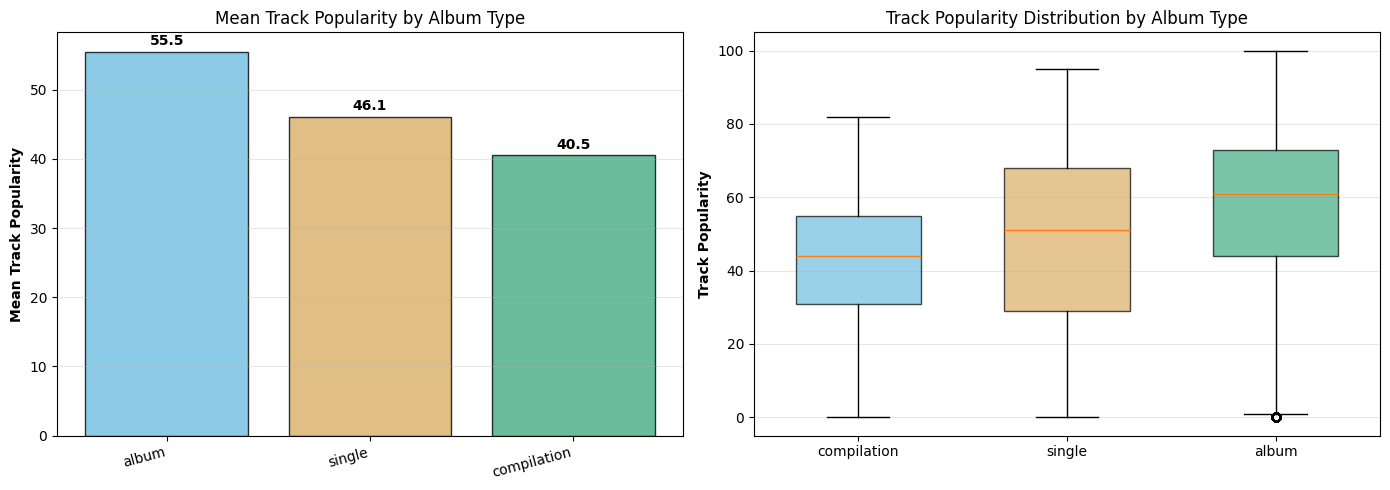

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q1_mean_pop = q1_stats['track_popularity_mean'].sort_values(ascending=False)
colors_q1 = ['#6FBEE0', '#DAAF65', '#42AB84']

axes[0].bar(range(len(q1_mean_pop)), q1_mean_pop.values, 
            color=colors_q1, alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(q1_mean_pop)))
axes[0].set_xticklabels(q1_mean_pop.index, rotation=15, ha='right')
axes[0].set_ylabel('Mean Track Popularity', fontweight='bold')
axes[0].set_title('Mean Track Popularity by Album Type')
axes[0].grid(axis='y', alpha=0.3)

for i, val in enumerate(q1_mean_pop.values):
    axes[0].text(i, val + 1, f'{val:.1f}', ha='center', fontweight='bold')

q1_album_data = df['album_type'].unique()
box_data = [df[df['album_type'] == atype]['track_popularity'] for atype in q1_album_data]
bp = axes[1].boxplot(box_data, labels=q1_album_data, patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], colors_q1):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Track Popularity', fontweight='bold')
axes[1].set_title('Track Popularity Distribution by Album Type')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


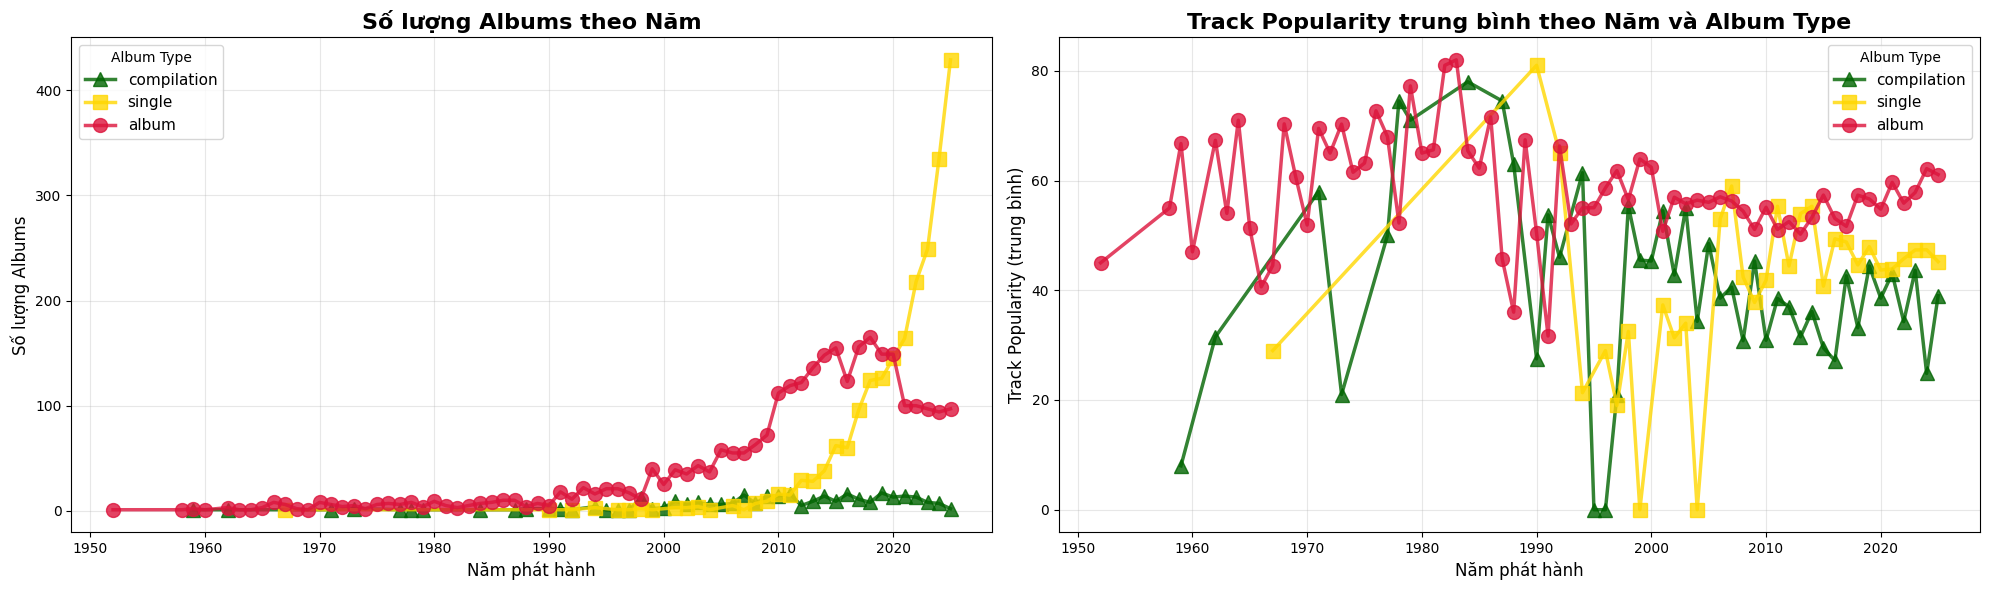

In [10]:
# Số lượng Albums duy nhất theo Năm
df['release_year'] = pd.to_datetime(df['album_release_date'], format='mixed', errors='coerce').dt.year
df_unique_albums = df.drop_duplicates(subset=['album_id'])
yearly_album_count = df_unique_albums.groupby(['release_year', 'album_type']).size().reset_index(name='album_count')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
# 1: Số lượng Albums duy nhất theo Năm 
colors_line = {'album': '#DC143C', 'single': '#FFD700', 'compilation': '#006400'}
markers = {'album': 'o', 'single': 's', 'compilation': '^'}
for album_type in df['album_type'].unique():
    data = yearly_album_count[yearly_album_count['album_type'] == album_type]
    ax1.plot(data['release_year'], data['album_count'], marker=markers.get(album_type, 'o'), label=album_type, linewidth=2.5, markersize=10, color=colors_line.get(album_type, 'gray'), alpha=0.8)

ax1.set_title('Số lượng Albums theo Năm', fontsize=16, fontweight='bold')
ax1.set_xlabel('Năm phát hành', fontsize=12)
ax1.set_ylabel('Số lượng Albums', fontsize=12)
ax1.legend(title='Album Type', fontsize=11, loc='best')
ax1.grid(True, alpha=0.3)

# 2: Track Popularity trung bình theo Năm và Album Type
yearly_popularity = df.groupby(['release_year', 'album_type'])['track_popularity'].mean().reset_index(name='avg_popularity')
for album_type in df['album_type'].unique():
    data = yearly_popularity[yearly_popularity['album_type'] == album_type]
    ax2.plot(data['release_year'], data['avg_popularity'], marker=markers.get(album_type, 'o'), label=album_type, linewidth=2.5, markersize=10, color=colors_line.get(album_type, 'gray'), alpha=0.8)
ax2.set_title('Track Popularity trung bình theo Năm và Album Type', fontsize=16, fontweight='bold')
ax2.set_xlabel('Năm phát hành', fontsize=12)
ax2.set_ylabel('Track Popularity (trung bình)', fontsize=12)
ax2.legend(title='Album Type', fontsize=11, loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**H0:** Không có sự khác biệt có ý nghĩa thống kê về độ phổ biến trung bình của bài hát giữa các loại album (Album, Single, Compilation).

$$H_0: \mu_{album} = \mu_{single} = \mu_{compilation}$$

**H1:** Có ít nhất một loại album có độ phổ biến trung bình khác biệt có ý nghĩa so với các loại còn lại.

$$H_1: \exists \, i \neq j : \mu_i \neq \mu_j$$

In [11]:
group_album = df[df['album_type'] == 'album']['track_popularity'].dropna()
group_single = df[df['album_type'] == 'single']['track_popularity'].dropna()
group_compilation = df[df['album_type'] == 'compilation']['track_popularity'].dropna()

data_groups = [group_album, group_single, group_compilation]
labels = ['Album', 'Single', 'Compilation']

print("Các Kiểm Định Thống Kê:\n")

# 1. ANOVA
f_stat, p_value_anova = f_oneway(group_album, group_single, group_compilation)
print("1. ANOVA (Một Chiều):")
print(f"   Giá trị F: {f_stat:.4f}")
print(f"   Giá trị P: {p_value_anova:.4e}")

if p_value_anova < 0.05:
    print(f"   Kết quả: Có sự khác biệt có ý nghĩa (p < 0.05)")
    means = [g.mean() for g in data_groups]
    max_idx = np.argmax(means)
    print(f"   Trung bình cao nhất: {labels[max_idx]} ({means[max_idx]:.2f})")

Các Kiểm Định Thống Kê:

1. ANOVA (Một Chiều):
   Giá trị F: 198.3060
   Giá trị P: 5.8560e-85
   Kết quả: Có sự khác biệt có ý nghĩa (p < 0.05)
   Trung bình cao nhất: Album (55.53)


**H0** Các phân phối độ phổ biến của bài hát giữa ba loại album (Album, Single, Compilation) là giống nhau.

$$H_0: F_{album}(x) = F_{single}(x) = F_{compilation}(x)$$

**H1** Có ít nhất một loại album có phân phối độ phổ biến khác biệt với các loại còn lại.

$$H_1: \exists \, i \neq j : F_i(x) \neq F_j(x)$$

In [12]:
# 2. Kruskal-Wallis
h_stat, p_value_kruskal = kruskal(group_album, group_single, group_compilation)
print(f"\n2. Kruskal-Wallis:")
print(f"   Giá trị H: {h_stat:.4f}")
print(f"   Giá trị P: {p_value_kruskal:.4e}")
print(f"   Kết quả: {'Có sự khác biệt có ý nghĩa' if p_value_kruskal < 0.05 else 'Không có sự khác biệt có ý nghĩa'}")


2. Kruskal-Wallis:
   Giá trị H: 418.0297
   Giá trị P: 1.6827e-91
   Kết quả: Có sự khác biệt có ý nghĩa


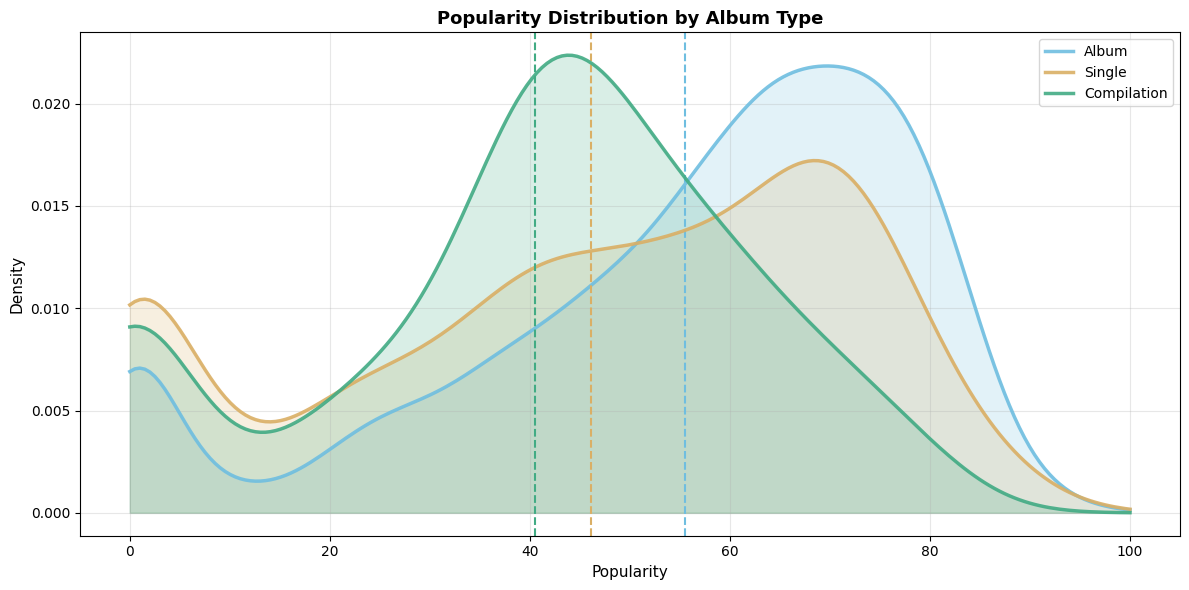

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#6FBEE0', '#DAAF65', '#42AB84']
x_range = np.linspace(0, 100, 200)

for data, label, color in zip(data_groups, labels, colors):
    kde = gaussian_kde(data)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2.5, label=label, alpha=0.9)
    ax.fill_between(x_range, kde(x_range), alpha=0.2, color=color)
    ax.axvline(data.mean(), color=color, linestyle='--', linewidth=1.5)

ax.set_title('Popularity Distribution by Album Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Popularity', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### C. Kết quả & Giải thích

**Câu trả lời:** Album có độ phổ biến cao nhất với độ phổ biến trung bình 55.5, trong khi đĩa đơn ở mức 46.1 và tuyển tập thấp nhất 40.5.

**Phát hiện chính:**

 - Album đầy đủ vượt trội hơn đĩa đơn và tuyển tập

 - Tuyển tập có độ phổ biến thấp nhất mặc dù thường tập hợp các bài hát "hay nhất" - có thể do sở thích của người nghe đối với trải nghiệm album gắn kết hay do tuyển tập bị coi là phát hành lại không có nội dung mới.

 - Số lượng Single phát hành tăng nhanh, nhưng độ phổ biến trung bình lại thấp hơn. Điều này cho thấy thị trường đang bị "loãng" bởi rất nhiều Single thất bại (có thể từ các nghệ sĩ mới), kéo độ phổ biến trung bình xuống thấp. Vì vậy, Album vẫn là lựa chọn an toàn và ổn định hơn để duy trì độ nổi tiếng cao.

- Kết quả kiểm định ANOVA và Kruskal-Wallis đều cho p-value (nhỏ hơn so với 0.05). Điều này khẳng định sự chênh lệch về độ phổ biến giữa Album, Single và Compilation là **thực tế và có ý nghĩa thống kê**, chứ không phải ngẫu nhiên.

**Ý nghĩa thực tiễn:**

 - Nghệ sĩ nên cân nhắc phát hành album đầy đủ thay vì chỉ đĩa đơn khi có đủ tài liệu - dữ liệu cho thấy album đầy đủ đạt độ phổ biến cao hơn mặc dù yêu cầu cam kết nghe lâu hơn. Các hãng thu âm đầu tư vào sản xuất album có thể mong đợi lợi nhuận về độ phổ biến tốt hơn so với chiến lược chỉ phát hành đĩa đơn.

 - Tuy nhiên, cần lưu ý rằng đĩa đơn có số lượng cao hơn (2,248 bài) so với album trong những năm gần đây - xu hướng phát hành đĩa đơn có thể do cân nhắc chi phí và kinh tế phát trực tuyến, không chỉ tiềm năng độ phổ biến.

**Hạn chế:**

 - Phân tích không tính đến ngân sách quảng bá - album thường có chi phí tiếp thị lớn hơn so với đĩa đơn. Cũng không phân biệt album đầu tay so với album của nghệ sĩ đã thành danh. Tập dữ liệu có thể thiên vị về các album thành công (thiên kiến sống sót).

---

## 4.5 Câu hỏi 2: Explicit content và popularity

### Question

Những bài hát có explicit content (`explicit` = True) có độ phổ biến cao hơn hay thấp hơn so với những bài không explicit?

### A. Tiền xử lý

Kiểm tra phân bố các bài hát có nội dung nhạy cảm so với không nhạy cảm và tính thống kê để so sánh.

1. **Kiểm tra phân bố**: Xác định tỷ lệ nhạy cảm so với không nhạy cảm trong tập dữ liệu
2. **Tính thống kê**: Tính trung bình, trung vị, độ lệch chuẩn của track_popularity cho cả 2 nhóm
3. **Chuẩn bị dữ liệu so sánh**: Tạo tập dữ liệu cho kiểm định thống kê và trực quan hóa

In [14]:
q2_explicit_dist = df['explicit'].value_counts()
print('Distribution:')
print(q2_explicit_dist)
print(f'\nExplicit: {q2_explicit_dist[True] / len(df) * 100:.2f}%')
print(f'Non-Explicit: {q2_explicit_dist[False] / len(df) * 100:.2f}%')

Distribution:
explicit
False    6582
True     2190
Name: count, dtype: int64

Explicit: 24.97%
Non-Explicit: 75.03%


In [15]:
q2_stats = df.groupby('explicit').agg({
    'track_popularity': ['mean', 'median', 'std', 'count'],
    'artist_popularity': ['mean', 'median']
}).round(2)

q2_stats.columns = ['_'.join(col) for col in q2_stats.columns]
q2_stats


,track_popularity_mean,track_popularity_median,track_popularity_std,track_popularity_count,artist_popularity_mean,artist_popularity_median
explicit,,,,,,
False,50.48,55.0,24.27,6582,68.03,72.0
True,57.53,64.0,22.64,2190,75.82,81.0


### B. Phân tích

**Phương pháp phân tích:**

So sánh độ phổ biến bài hát giữa nội dung nhạy cảm và không nhạy cảm để xác định loại nội dung nào có độ phổ biến cao hơn:

1. **So sánh theo nhóm**: So sánh trung bình và trung vị track_popularity giữa nhạy cảm và không nhạy cảm
2. **Trực quan hóa phân bố**: Biểu đồ hộp và biểu đồ tần suất để so sánh toàn bộ phân bố
3. **Kiểm định thống kê:** Chứng minh giả định bằng thống kê

**Kết quả mong đợi:**
- Biểu đồ cột: So sánh độ phổ biến trung bình
- Biểu đồ hộp: So sánh phân bố
- Biểu đồ đường: Mức độ phổ biến theo từng năm

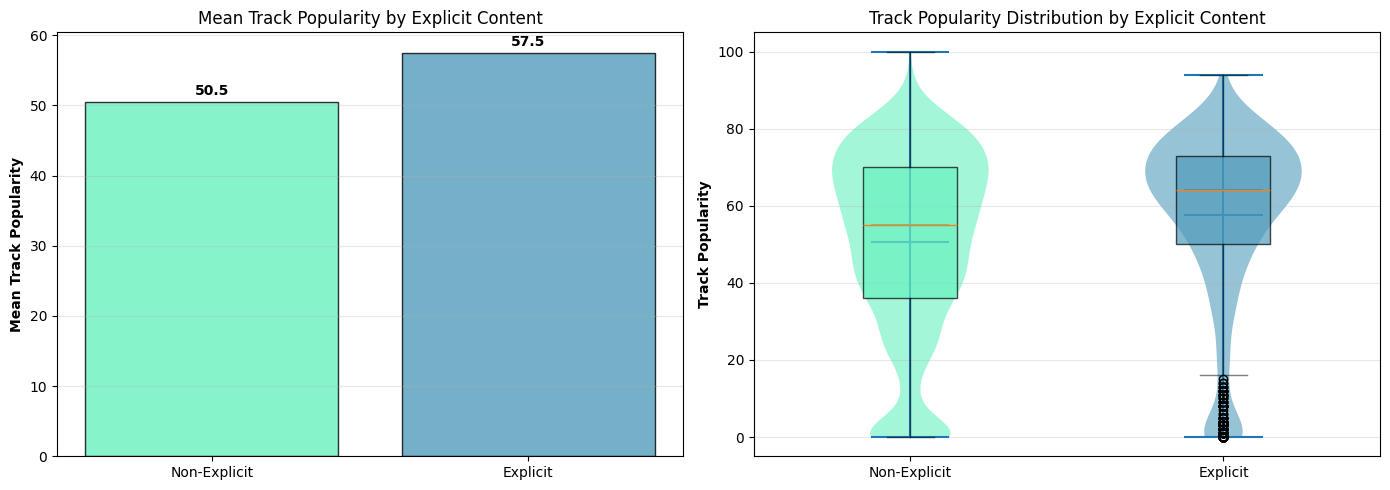

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q2_explicit = df[df['explicit'] == True]['track_popularity']
q2_non_explicit = df[df['explicit'] == False]['track_popularity']

# Subplot 1: Bar chart of mean popularity
q2_means = pd.Series({
    'Non-Explicit': q2_non_explicit.mean(),
    'Explicit': q2_explicit.mean()
})
colors_q2 = ['#68F1BF', '#519CBA']

axes[0].bar(range(len(q2_means)), q2_means.values, 
            color=colors_q2, alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(q2_means)))
axes[0].set_xticklabels(q2_means.index, rotation=0)
axes[0].set_ylabel('Mean Track Popularity', fontweight='bold')
axes[0].set_title('Mean Track Popularity by Explicit Content')
axes[0].grid(axis='y', alpha=0.3)

for i, val in enumerate(q2_means.values):
    axes[0].text(i, val + 1, f'{val:.1f}', ha='center', fontweight='bold')

# Subplot 2: Violin plot with boxplot inside
q2_data = [q2_non_explicit, q2_explicit]
parts = axes[1].violinplot(q2_data, positions=[0, 1], showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_q2[i])
    pc.set_alpha(0.6)

# Add boxplot inside
bp = axes[1].boxplot(q2_data, positions=[0, 1], widths=0.3, patch_artist=True,
                      boxprops=dict(alpha=0.7),
                      whiskerprops=dict(alpha=0.5),
                      capprops=dict(alpha=0.5))

for patch, color in zip(bp['boxes'], colors_q2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Explicit', 'Explicit'])
axes[1].set_ylabel('Track Popularity', fontweight='bold')
axes[1].set_title('Track Popularity Distribution by Explicit Content')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

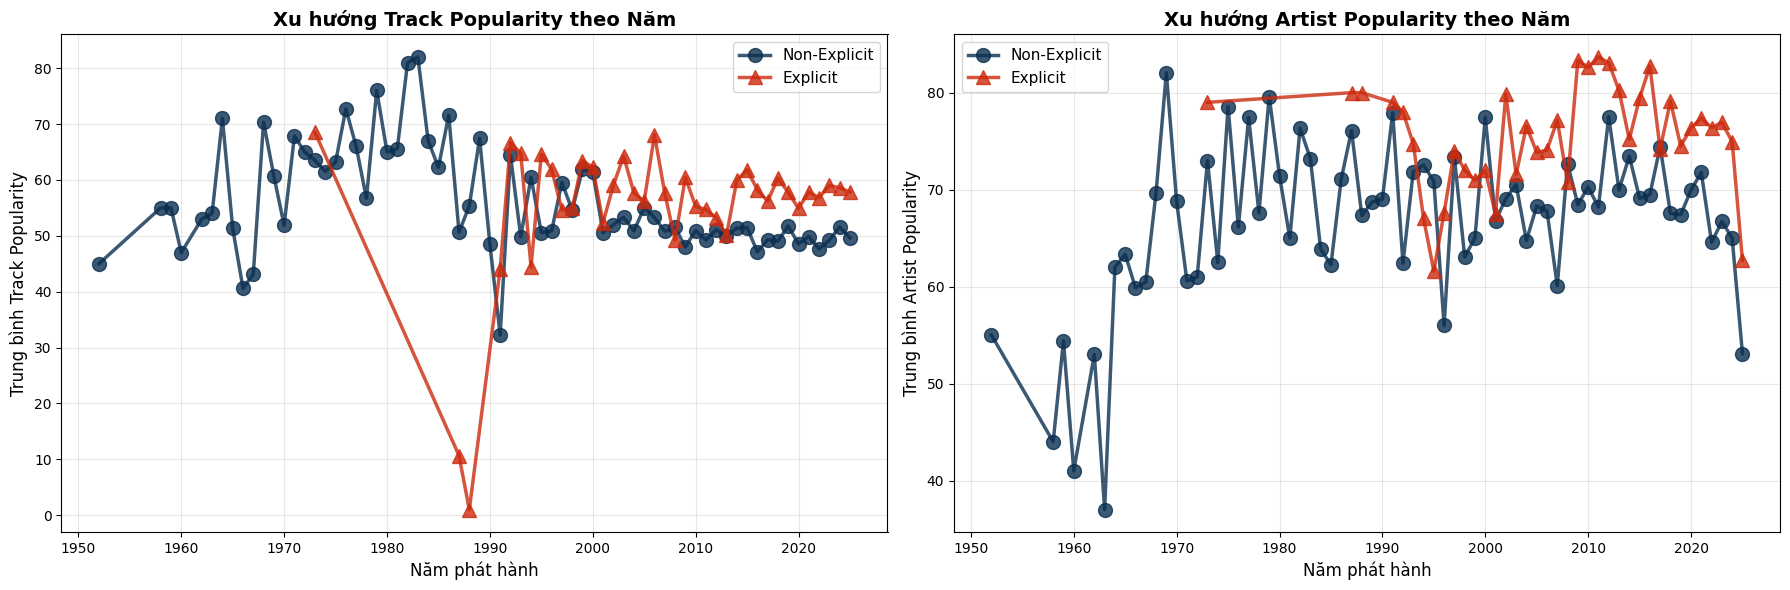

In [17]:
# Xu hướng Popularity theo năm
df['release_year'] = pd.to_datetime(df['album_release_date'], format='mixed', errors='coerce').dt.year
# Tính theo năm
yearly_track_pop = df.groupby(['release_year', 'explicit'])['track_popularity'].mean().reset_index()
yearly_artist_pop = df.groupby(['release_year', 'explicit'])['artist_popularity'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors_line = {False: "#0B2F50", True: "#CC2A0D"}
markers = {False: 'o', True: '^'}
# 1. Line Chart - Track Popularity theo Năm
for explicit_val in [False, True]:
    data = yearly_track_pop[yearly_track_pop['explicit'] == explicit_val]
    label = 'Explicit' if explicit_val else 'Non-Explicit'
    axes[0].plot(data['release_year'], data['track_popularity'],  marker=markers[explicit_val], label=label, linewidth=2.5, markersize=10, color=colors_line[explicit_val], alpha=0.8)

axes[0].set_title('Xu hướng Track Popularity theo Năm', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Năm phát hành', fontsize=12)
axes[0].set_ylabel('Trung bình Track Popularity', fontsize=12)
axes[0].legend(fontsize=11, loc='best')
axes[0].grid(True, alpha=0.3)
# 2. Line Chart - Artist Popularity theo Năm
for explicit_val in [False, True]:
    data = yearly_artist_pop[yearly_artist_pop['explicit'] == explicit_val]
    label = 'Explicit' if explicit_val else 'Non-Explicit'
    axes[1].plot(data['release_year'], data['artist_popularity'],  marker=markers[explicit_val], label=label, linewidth=2.5, markersize=10, color=colors_line[explicit_val], alpha=0.8)

axes[1].set_title('Xu hướng Artist Popularity theo Năm', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Năm phát hành', fontsize=12)
axes[1].set_ylabel('Trung bình Artist Popularity', fontsize=12)
axes[1].legend(fontsize=11, loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Kiểm định 1 phía: Explicit > Non-Explicit**

- **H0**: Độ phổ biến *Explicit* ≤ Độ phổ biến *Non-Explicit*
- **H1**: Độ phổ biến *Explicit* > Độ phổ biến *Non-Explicit*


In [18]:
# Các Kiểm Định Thống Kê
from scipy.stats import ttest_ind, mannwhitneyu
import numpy as np

# 1. Kiểm Định T
t_stat, p_value_ttest = ttest_ind(q2_explicit, q2_non_explicit, alternative='greater')
print("1. Kiểm định T:")
print(f"Giá trị T: {t_stat:.4f}")
print(f"Giá trị P: {p_value_ttest:.4e}")
print(f"Kết quả: {'Bác bỏ H0' if p_value_ttest < 0.05 else 'Chấp nhận H0'} (p < 0.05)")

# 2. Kiểm Định Mann-Whitney U
u_stat, p_value_mann = mannwhitneyu(q2_explicit, q2_non_explicit, alternative='greater')
print("\n2. Kiểm định Mann-Whitney U:")
print(f"Giá trị U: {u_stat:.4f}")
print(f"Giá trị P: {p_value_mann:.4e}")
print(f"Kết quả: {'Bác bỏ H0' if p_value_mann < 0.05 else 'Chấp nhận H0'} (p < 0.05)")

1. Kiểm định T:
Giá trị T: 11.9734
Giá trị P: 4.4089e-33
Kết quả: Bác bỏ H0 (p < 0.05)

2. Kiểm định Mann-Whitney U:
Giá trị U: 8568838.0000
Giá trị P: 1.8213e-40
Kết quả: Bác bỏ H0 (p < 0.05)


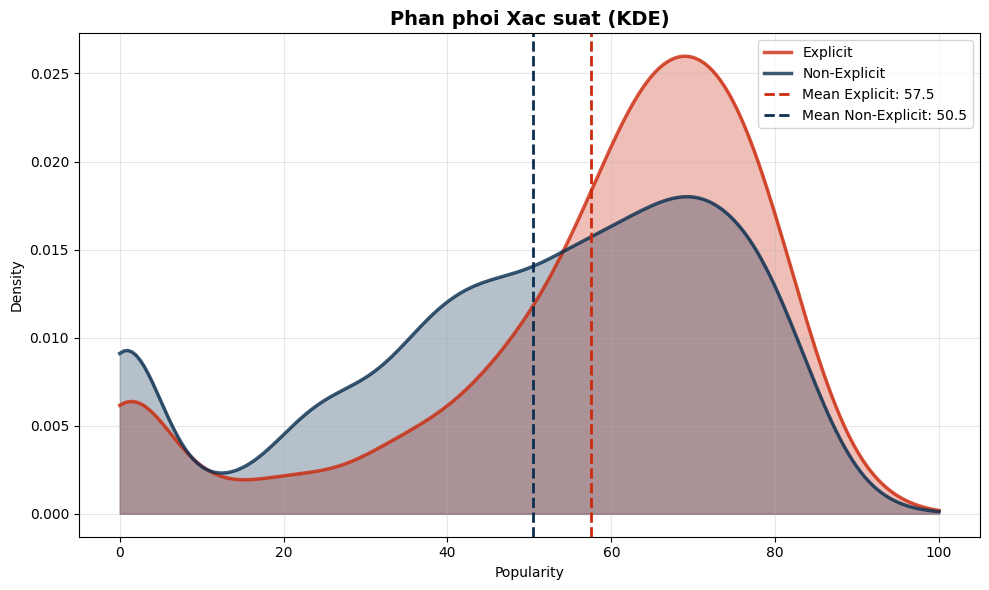

In [19]:
kde_explicit = gaussian_kde(q2_explicit.dropna())
kde_non_explicit = gaussian_kde(q2_non_explicit.dropna())
x_range = np.linspace(0, 100, 200)

plt.figure(figsize=(10, 6))
plt.plot(x_range, kde_explicit(x_range), color='#CC2A0D', linewidth=2.5, label='Explicit', alpha=0.8)
plt.fill_between(x_range, kde_explicit(x_range), alpha=0.3, color='#CC2A0D')
plt.plot(x_range, kde_non_explicit(x_range), color='#0B2F50', linewidth=2.5, label='Non-Explicit', alpha=0.8)
plt.fill_between(x_range, kde_non_explicit(x_range), alpha=0.3, color='#0B2F50')
plt.axvline(q2_explicit.mean(), color='#CC2A0D', linestyle='--', linewidth=2, label=f'Mean Explicit: {q2_explicit.mean():.1f}')
plt.axvline(q2_non_explicit.mean(), color='#0B2F50', linestyle='--', linewidth=2, label=f'Mean Non-Explicit: {q2_non_explicit.mean():.1f}')
plt.title('Phan phoi Xac suat (KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Popularity')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### C. Kết quả & Giải thích

**Câu trả lời:** Các bài hát có nội dung nhạy cảm có độ phổ biến cao hơn đáng kể so với các bài hát không nhạy cảm.

**Phát hiện chính:**

Nội dung nhạy cảm đạt độ phổ biến trung bình 57.5 so với không nhạy cảm 50.5 - chênh lệch 7 điểm. 

Trung vị cũng cho thấy mô hình tương tự: nhạy cảm (64) vượt không nhạy cảm (55) 9 điểm. Biểu đồ hộp cho thấy các bài hát nhạy cảm có phân bố tập trung ở phạm vi cao hơn với Q3=73 so với Q3=70 của không nhạy cảm.

Độ nổi tiếng của bài hát và nghệ sĩ cũng cao hơn đối với nội dung nhạy cảm (75.8 so với 68.0), cho thấy rằng các nghệ sĩ nổi tiếng hơn và có thể tự do hơn để phát hành những bài hát có chứa nội dung nhạy cảm mà vẫn duy trì được mức độ phổ biến.

**Ý nghĩa thực tiễn:**

Dữ liệu cho thấy nội dung nhạy cảm không làm giảm độ phổ biến như nhiều người lo ngại - trái lại còn liên kết với độ phổ biến cao hơn. Điều này có thể do các nghệ sĩ đã thành danh (đã có lượng người hâm mộ) thoải mái hơn với lời bài hát nhạy cảm, hoặc do nội dung nhạy cảm cộng hưởng nhiều hơn với nhân khẩu học phát trực tuyến cốt lõi (khán giả trẻ hơn).

Nghệ sĩ không cần tự kiểm duyệt để theo đuổi độ phổ biến - biểu đạt chân thực qua lời bài hát nhạy cảm không bị phạt về mặt thành công thương mại. Các hãng thu âm và nền tảng cũng nên đánh giá lại những lo ngại về việc nội dung nhạy cảm hạn chế phạm vi tiếp cận.

**Hạn chế:**

Tương quan không có nghĩa là nhân quả - nội dung nhạy cảm không trực tiếp gây ra độ phổ biến cao hơn. Có thể có các yếu tố gây nhiễu như thể loại (hip-hop thường nhạy cảm và phổ biến), vị thế nghệ sĩ, hoặc nhân khẩu học mục tiêu. Phân tích không kiểm soát các biến này.

---

## 4.6 Câu hỏi 3: Golden duration analysis

### Question

Có tồn tại một khoảng thời lượng golden duration nào cho track mà trong đó những bài hát có độ phổ biến trung bình cao nhất không? Nếu có, khoảng này là bao nhiêu phút?

### A. Tiền xử lý

Sử dụng dữ liệu đã được làm sạch ở phần 4.3. Không cần tiền xử lý thêm.

### B. Phân tích

Phân tích thời lượng theo 2 cấp độ:

1. **Phân tích tổng quát**: Chia thời lượng thành 5 nhóm (<2p, 2-3p, 3-4p, 4-5p, >5p) để xem xu hướng chung
2. **Phân tích chi tiết**: Chia thời lượng thành các khoảng 0.5 phút để tìm thời lượng vàng chính xác
3. **Trực quan hóa**: Biểu đồ cột cho các nhóm, biểu đồ phân tán + đường xu hướng cho phân tích chi tiết

In [20]:
q3_df = df[['duration_min', 'track_popularity']].copy()

q3_df['duration_group'] = pd.cut(q3_df['duration_min'], 
                                   bins=[0, 2, 3, 4, 5, 100],
                                   labels=['<2p', '2-3p', '3-4p', '4-5p', '>5p'])

q3_group_stats = q3_df.groupby('duration_group')['track_popularity'].agg(['mean', 'median', 'count'])
q3_group_stats

,mean,median,count
duration_group,,,
<2p,38.212670,41.0,442
2-3p,48.407075,52.0,2120
3-4p,54.816291,62.0,4039
4-5p,55.330670,61.0,1627
>5p,50.255515,56.0,544


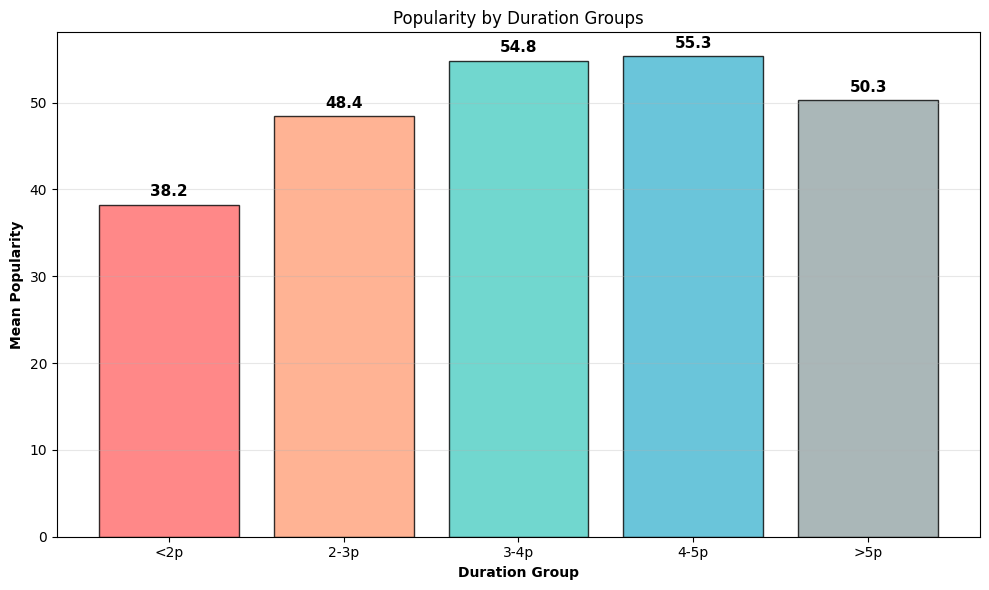

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(q3_group_stats))
bars = ax.bar(x_pos, q3_group_stats['mean'], 
               color=['#FF6B6B', '#FFA07A', '#4ECDC4', '#45B7D1', '#95A5A6'], 
               alpha=0.8, edgecolor='black')

for i, (bar, val) in enumerate(zip(bars, q3_group_stats['mean'])):
    ax.text(bar.get_x() + bar.get_width()/2., val + 1,
            f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Duration Group', fontweight='bold')
ax.set_ylabel('Mean Popularity', fontweight='bold')
ax.set_title('Popularity by Duration Groups')
ax.set_xticks(x_pos)
ax.set_xticklabels(q3_group_stats.index)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
bins = np.arange(0, 8, 0.5)
q3_df['duration_bin'] = pd.cut(q3_df['duration_min'], bins=bins)

q3_detailed_stats = q3_df.groupby('duration_bin')['track_popularity'].agg(['mean', 'count'])
q3_detailed_stats = q3_detailed_stats[q3_detailed_stats['count'] >= 30].sort_values('mean', ascending=False)

q3_detailed_stats.head(10)

,mean,count
duration_bin,,
"(4.0, 4.5]",55.883871,1085
"(3.5, 4.0]",55.627000,2000
"(4.5, 5.0]",54.223247,542
"(3.0, 3.5]",54.021089,2039
"(5.0, 5.5]",53.504132,242
"(2.5, 3.0]",50.478639,1381
"(6.0, 6.5]",48.666667,51
"(5.5, 6.0]",47.455224,134
"(6.5, 7.0]",45.108108,37


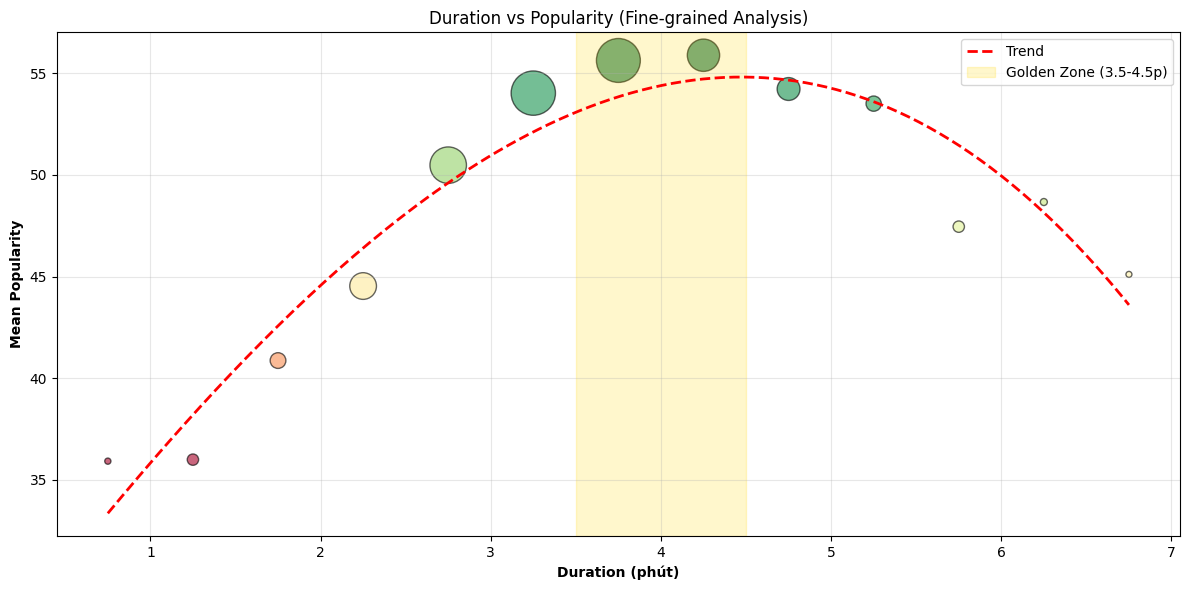

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

valid_stats = q3_detailed_stats[q3_detailed_stats.index.map(lambda x: x.right <= 7)]
bin_mids = [interval.mid for interval in valid_stats.index]

ax.scatter(bin_mids, valid_stats['mean'], s=valid_stats['count']/2, 
           c=valid_stats['mean'], cmap='RdYlGn', alpha=0.6, edgecolors='black')

z = np.polyfit(bin_mids, valid_stats['mean'], 3)
p = np.poly1d(z)
x_smooth = np.linspace(min(bin_mids), max(bin_mids), 200)
ax.plot(x_smooth, p(x_smooth), 'r--', linewidth=2, label='Trend')

ax.axvspan(3.5, 4.5, alpha=0.2, color='gold', label='Golden Zone (3.5-4.5p)')

ax.set_xlabel('Duration (phút)', fontweight='bold')
ax.set_ylabel('Mean Popularity', fontweight='bold')
ax.set_title('Duration vs Popularity (Fine-grained Analysis)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**H0** Các phân phối độ phổ biến của bài hát giữa các nhóm thời lượng khác nhau (<2 phút, 2-3 phút, 3-4 phút, 4-5 phút, >5 phút) là giống nhau.

$$H_0: F_{<2p}(x) = F_{2-3p}(x) = F_{3-4p}(x) = F_{4-5p}(x) = F_{>5p}(x)$$

**H1** Có ít nhất một nhóm thời lượng có phân phối độ phổ biến khác biệt với các nhóm còn lại.

$$H_1: \exists \, i \neq j : F_i(x) \neq F_j(x)$$

In [24]:
# Kiểm Định Kruskal-Wallis
from scipy.stats import kruskal

duration_test_groups = []
duration_labels = []
for dur_group in ['<2p', '2-3p', '3-4p', '4-5p', '>5p']:
    group_data = q3_df[q3_df['duration_group'] == dur_group]['track_popularity'].dropna()
    if len(group_data) > 0:
        duration_test_groups.append(group_data)
        duration_labels.append(dur_group)

print("Kiểm Định Kruskal-Wallis:\n")

h_stat, p_value_kw = kruskal(*duration_test_groups)
print(f"Giá trị H: {h_stat:.4f}")
print(f"Giá trị P: {p_value_kw:.4e}")

if p_value_kw < 0.05:
    print(f"Kết quả: Có sự khác biệt có ý nghĩa giữa các nhóm (p < 0.05)")
    means = [g.mean() for g in duration_test_groups]
    max_idx = np.argmax(means)
    print(f"Độ phổ biến trung bình cao nhất: {duration_labels[max_idx]} ({means[max_idx]:.2f})")
else:
    print("Kết quả: Không có sự khác biệt có ý nghĩa")

Kiểm Định Kruskal-Wallis:

Giá trị H: 348.3981
Giá trị P: 3.8890e-74
Kết quả: Có sự khác biệt có ý nghĩa giữa các nhóm (p < 0.05)
Độ phổ biến trung bình cao nhất: 4-5p (55.33)


### C. Kết quả & Giải thích

**Câu trả lời:** Có tồn tại thời lượng vàng - khoảng **3.5 - 4.5 phút** có độ phổ biến trung bình cao nhất (~55.6-55.9).

**Phát hiện chính:**

Độ phổ biến tăng dần từ bài hát ngắn (<2p: 38.2) đến trung bình (3-4p: 54.8) và đạt đỉnh ở 4-5p (55.3), sau đó giảm xuống khi bài hát quá dài (>5p: 50.3). Phân tích chi tiết cho thấy đỉnh chính xác ở 4.0-4.5 phút với độ phổ biến 55.9.

**Ý nghĩa thực tiễn:**

Nhà sản xuất và nhạc sĩ nên nhắm đến thời lượng 3.5-4.5 phút để tối ưu hóa độ phổ biến. Bài hát dưới 2 phút có xu hướng bị coi là thiếu nội dung (độ phổ biến thấp hơn 17 điểm so với vùng vàng), trong khi bài trên 5 phút có thể khiến người nghe bỏ qua hoặc mất hứng thú (giảm 5 điểm độ phổ biến).

**Hạn chế:**

Phân tích này không phân biệt thể loại - có thể một số thể loại (EDM, cổ điển) có thời lượng tối ưu khác. Tập dữ liệu tập trung vào pop/hip-hop đại chúng nên các phát hiện có thể không khái quát cho tất cả các phong cách âm nhạc.

---

## 4.7 Câu hỏi 4: Số lượng bài hát và độ nổi tiếng nghệ sĩ

### Question

Nghệ sĩ phát hành nhiều bài hát hơn thì có đạt được độ nổi tiếng trung bình cao hơn so với nghệ sĩ phát hành ít bài hơn không?

### A. Tiền xử lý

Tổng hợp dữ liệu theo nghệ sĩ để đếm số bài hát và tính độ phổ biến trung bình cho mỗi nghệ sĩ.

In [25]:
q4_artist_stats = df.groupby('artist_name').agg({
    'track_id': 'count',
    'artist_popularity': 'first',
    'artist_followers': 'first'
}).rename(columns={'track_id': 'track_count'})

q4_artist_stats['output_strategy'] = pd.cut(q4_artist_stats['track_count'], 
                                              bins=[0, 20, 50, 100, 1000],
                                              labels=['Low (1-20)', 'Medium (21-50)', 'High (51-100)', 'Very High (>100)'])

q4_artist_stats.head()

,track_count,artist_popularity,artist_followers,output_strategy
artist_name,,,,
$uicideboy$,2,83,8957416,Low (1-20)
'Ery Noice,1,25,11720,Low (1-20)
(((()))),1,51,49519,Low (1-20)
*NSYNC,1,69,3088613,Low (1-20)
-,1,28,714,Low (1-20)


### B. Phân tích

**Phương pháp phân tích:**

Để trả lời câu hỏi này, nhóm sử dụng 2 phương pháp:

1. **So sánh theo nhóm**: Chia nghệ sĩ thành 4 nhóm theo chiến lược sản xuất (Thấp: 1-20 bài, Trung bình: 21-50, Cao: 51-100, Rất cao: >100) để so sánh độ phổ biến trung bình/trung vị của nghệ sĩ giữa các nhóm
2. **Phân tích tương quan**: Biểu đồ phân tán giữa số lượng bài hát và độ phổ biến nghệ sĩ với đường xu hướng để thấy mối quan hệ

**Kết quả mong đợi:**
- Bảng thống kê: Trung bình, trung vị, độ lệch chuẩn của độ phổ biến nghệ sĩ và người theo dõi cho mỗi nhóm chiến lược sản xuất
- Trực quan hóa 1: Biểu đồ cột so sánh độ phổ biến trung bình của nghệ sĩ qua các nhóm
- Trực quan hóa 2: Biểu đồ phân tán với đường xu hướng hiển thị mối quan hệ giữa số lượng bài hát và độ phổ biến nghệ sĩ

**Lý do:** Phân tích theo nhóm giúp thấy sự khác biệt rõ ràng giữa các chiến lược, trong khi biểu đồ phân tán tiết lộ mô hình mối quan hệ chi tiết (tuyến tính, bậc hai, hoặc bão hòa).

In [26]:
q4_strategy_stats = q4_artist_stats.groupby('output_strategy').agg({
    'artist_popularity': ['mean', 'median', 'std'],
    'artist_followers': ['mean', 'median'],
    'track_count': 'count'
}).round(2)

q4_strategy_stats.columns = ['_'.join(col) for col in q4_strategy_stats.columns]
q4_strategy_stats

,artist_popularity_mean,artist_popularity_median,artist_popularity_std,artist_followers_mean,artist_followers_median,track_count_count
output_strategy,,,,,,
Low (1-20),52.94,57.0,19.56,2.375346e+06,391063.5,2484
Medium (21-50),79.84,82.5,8.45,2.543166e+07,22876939.0,44
High (51-100),87.00,88.0,4.53,6.386942e+07,50411829.0,16
Very High (>100),94.33,93.0,5.13,1.218964e+08,112918137.0,3


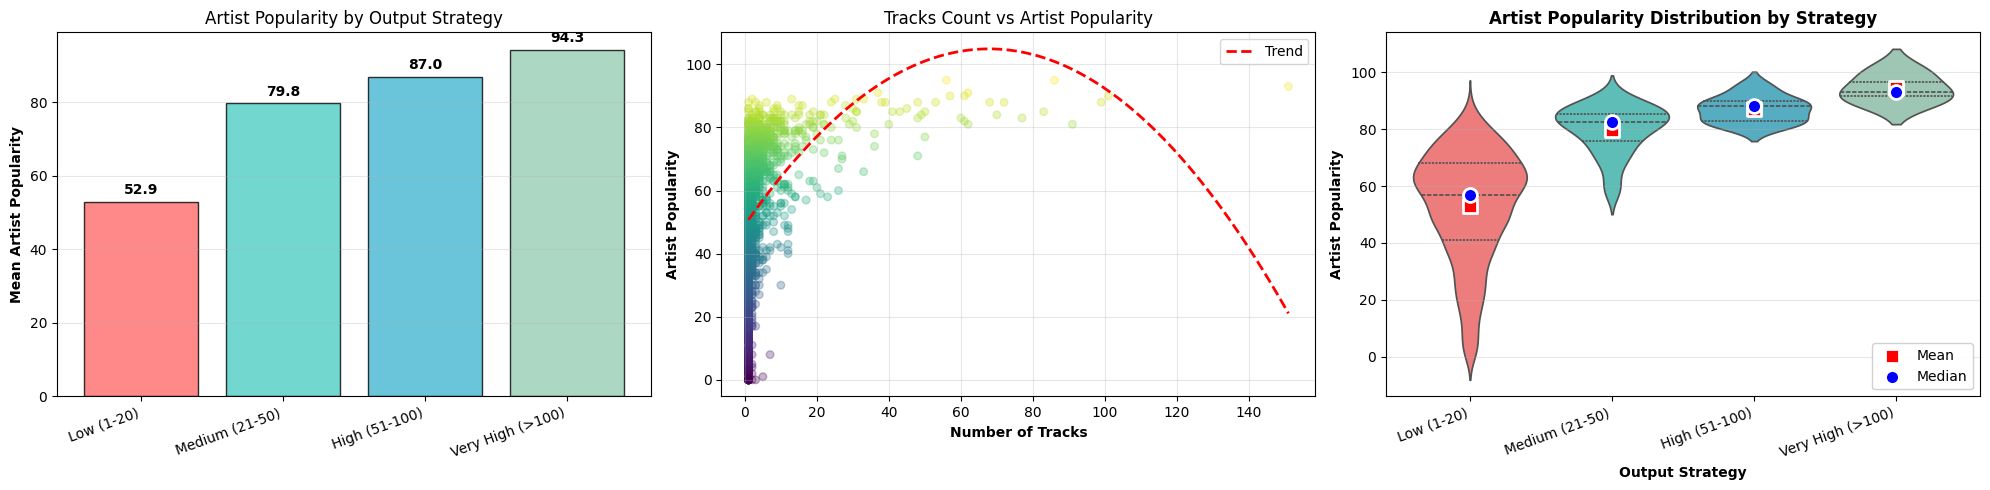

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].bar(range(len(q4_strategy_stats)), q4_strategy_stats['artist_popularity_mean'],
            color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(q4_strategy_stats)))
axes[0].set_xticklabels(q4_strategy_stats.index, rotation=20, ha='right')
axes[0].set_ylabel('Mean Artist Popularity', fontweight='bold')
axes[0].set_title('Artist Popularity by Output Strategy')
axes[0].grid(axis='y', alpha=0.3)

for i, val in enumerate(q4_strategy_stats['artist_popularity_mean']):
    axes[0].text(i, val + 2, f'{val:.1f}', ha='center', fontweight='bold')

q4_plot_df = q4_artist_stats[q4_artist_stats['track_count'] <= 200]
axes[1].scatter(q4_plot_df['track_count'], q4_plot_df['artist_popularity'], 
                alpha=0.3, s=30, c=q4_plot_df['artist_popularity'], cmap='viridis')

z = np.polyfit(q4_plot_df['track_count'], q4_plot_df['artist_popularity'], 2)
p = np.poly1d(z)
x_line = np.linspace(q4_plot_df['track_count'].min(), q4_plot_df['track_count'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')

axes[1].set_xlabel('Number of Tracks', fontweight='bold')
axes[1].set_ylabel('Artist Popularity', fontweight='bold')
axes[1].set_title('Tracks Count vs Artist Popularity')
axes[1].legend()
axes[1].grid(alpha=0.3)

strategy_order = ['Low (1-20)', 'Medium (21-50)', 'High (51-100)', 'Very High (>100)']
sns.violinplot(data=q4_artist_stats, x='output_strategy', y='artist_popularity', order=strategy_order,
               palette=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], ax=axes[2], inner='quartile')

# Vẽ thêm mean và median cho mỗi strategy
for i, strategy in enumerate(strategy_order):
    strategy_data = q4_artist_stats[q4_artist_stats['output_strategy'] == strategy]['artist_popularity']
    mean_val = strategy_data.mean()
    median_val = strategy_data.median()
    
    # Vẽ mean (hình vuông đỏ)
    axes[2].scatter(i, mean_val, color='red', s=100, marker='s', zorder=3, 
                    edgecolors='white', linewidths=2, label='Mean' if i == 0 else '')
    # Vẽ median (hình tròn xanh)
    axes[2].scatter(i, median_val, color='blue', s=100, marker='o', zorder=3, 
                    edgecolors='white', linewidths=2, label='Median' if i == 0 else '')

axes[2].set_title('Artist Popularity Distribution by Strategy', fontweight='bold')
axes[2].set_xlabel('Output Strategy', fontweight='bold')
axes[2].set_ylabel('Artist Popularity', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=20, ha='right')
axes[2].grid(alpha=0.3, axis='y')
axes[2].legend(loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()

**H0:** Các phân phối độ phổ biến của nghệ sĩ giữa các nhóm chiến lược sản xuất khác nhau (Low 1-20 bài, Medium 21-50 bài, High 51-100 bài, Very High >100 bài) là giống nhau.

$$H_0: F_{Low}(x) = F_{Medium}(x) = F_{High}(x) = F_{VeryHigh}(x)$$

**H1:** Có ít nhất một nhóm chiến lược sản xuất có phân phối độ phổ biến nghệ sĩ khác biệt với các nhóm còn lại.

$$H_1: \exists \, i \neq j : F_i(x) \neq F_j(x)$$

In [28]:
strategy_test_groups = []
strategy_labels = []
for strategy in ['Low (1-20)', 'Medium (21-50)', 'High (51-100)', 'Very High (>100)']:
    group_data = q4_artist_stats[q4_artist_stats['output_strategy'] == strategy]['artist_popularity'].dropna()
    if len(group_data) > 0:
        strategy_test_groups.append(group_data)
        strategy_labels.append(strategy)

print("Kiểm Định Kruskal-Wallis:\n")

h_stat_q4, p_value_kw_q4 = kruskal(*strategy_test_groups)
print(f"Giá trị H: {h_stat_q4:.4f}")
print(f"Giá trị P: {p_value_kw_q4:.4e}")

if p_value_kw_q4 < 0.05:
    print(f"Kết quả: Có sự khác biệt có ý nghĩa giữa các nhóm (p < 0.05)")
    means_q4 = [g.mean() for g in strategy_test_groups]
    max_idx_q4 = np.argmax(means_q4)
    print(f"Độ phổ biến trung bình cao nhất: {strategy_labels[max_idx_q4]} ({means_q4[max_idx_q4]:.2f})")
else:
    print("Kết quả: Không có sự khác biệt có ý nghĩa")

Kiểm Định Kruskal-Wallis:

Giá trị H: 145.3303
Giá trị P: 2.6791e-31
Kết quả: Có sự khác biệt có ý nghĩa giữa các nhóm (p < 0.05)
Độ phổ biến trung bình cao nhất: Very High (>100) (94.33)


### C. Kết quả & Giải thích

**Câu trả lời:** Có, nghệ sĩ phát hành nhiều bài hát hơn đạt được độ phổ biến nghệ sĩ cao hơn đáng kể.

**Phát hiện chính:**

Độ phổ biến nghệ sĩ tăng mạnh theo số lượng bài hát: Sản lượng thấp (1-20 bài) có độ phổ biến trung bình 52.9, trong khi sản lượng Rất cao (>100 bài) đạt 94.3 - tăng gần gấp đôi. Sản lượng trung bình (21-50 bài) đã có độ phổ biến 79.8, cho thấy sản lượng nhất quán là yếu tố quan trọng để xây dựng danh tiếng nghệ sĩ.

Lượng người theo dõi nghệ sĩ cũng tăng theo cùng mô hình: Sản lượng thấp có trung bình 2.4 triệu người theo dõi, sản lượng Rất cao có 121.9 triệu - tăng hơn 50 lần, chứng tỏ chiến lược sản xuất năng suất không chỉ tăng điểm độ phổ biến mà còn xây dựng được lượng người hâm mộ khổng lồ.

Biểu đồ phân tán cho thấy mối quan hệ không hoàn toàn tuyến tính - có hiệu suất giảm dần sau ~100 bài hát, và một số nghệ sĩ với sản lượng thấp vẫn có độ phổ biến cao (có thể do chất lượng hoặc các bản hit lan truyền).

Biểu đồ violin cho thấy rằng các chiến lược medium, high, và very high có phân bố tập trung rất nhiều ở vùng 80-90. Trong khi đó chiến lược low chỉ tập trung quanh vùng 60-70 và có phương sai lớn. Điều này cho thấy rằng chiến lược sản xuất nhạc ổn định và đều đặn thực sự giúp người nghệ sĩ trở nên nổi tiếng hơn, trong khi chiến lược sản xuất ít khiến sự nổi tiếng đôi khi phụ thuộc vào may mắn.

**Ý nghĩa thực tiễn:**

Nghệ sĩ mới nổi nên nhắm đến việc phát hành nhất quán thay vì chỉ sản xuất một vài bài hát - dữ liệu cho thấy việc chuyển từ sản lượng Thấp sang Trung bình (21-50 bài) mang lại bước nhảy vọt lớn nhất về độ phổ biến (+26.9 điểm). Các hãng thu âm nên đầu tư vào các nghệ sĩ có khả năng duy trì sản lượng ổn định, vì đây là yếu tố dự báo mạnh mẽ cho thành công dài hạn.

**Hạn chế:**

Phân tích này không tính đến thời gian - nghệ sĩ có 100 bài trong 1 năm khác với 100 bài trong 10 năm. Cũng không phân biệt chất lượng - độ phổ biến cao có thể do số lượng hoặc do có các bản hit trong danh mục.

---

## 4.8 Câu hỏi 5: Classic songs vs Recent songs

### Question

Những bài hát phát hành từ 2009-2015 (classic songs) có còn giữ được độ phổ biến cao so với những bài hát phát hành từ 2020-2025 (recent songs) không?

### A. Tiền xử lý

Lọc dữ liệu theo 2 khoảng thời gian và loại bỏ các bài hát có độ phổ biến = 0 (bài hát chết).

In [29]:
q5_classic = df[(df['year'] >= 2009) & (df['year'] <= 2015)].copy()
q5_recent = df[(df['year'] >= 2020) & (df['year'] <= 2025)].copy()

q5_classic = q5_classic[q5_classic['track_popularity'] > 0]
q5_recent = q5_recent[q5_recent['track_popularity'] > 0]

print(f'Classic songs (2009-2015): {len(q5_classic):,} tracks')
print(f'Recent songs (2020-2025): {len(q5_recent):,} tracks')

Classic songs (2009-2015): 1,944 tracks
Recent songs (2020-2025): 3,182 tracks


### B. Phân tích

**Phương pháp phân tích:**

So sánh phân bố độ phổ biến giữa 2 khoảng thời gian sử dụng:

1. **Thống kê mô tả**: Trung bình, trung vị, tứ phân vị để so sánh xu hướng trung tâm và độ phân tán
2. **So sánh phân bố**: Biểu đồ hộp và biểu đồ tần suất để trực quan hóa toàn bộ phân bố

**Kết quả mong đợi:**
- Bảng thống kê tóm tắt so sánh kinh điển và gần đây
- Biểu đồ hộp hiển thị so sánh phân bố
- Biểu đồ tần suất chồng lớp hiển thị phân bố độ phổ biến cho cả 2 nhóm

**Lý do:** Biểu đồ hộp tiết lộ các giá trị ngoại lai và cấu trúc tứ phân vị, biểu đồ tần suất hiển thị hình dạng của phân bố (chuẩn, lệch, hai đỉnh).

In [30]:
q5_stats = pd.DataFrame({
    'Classic (2009-2015)': q5_classic['track_popularity'].describe(),
    'Recent (2020-2025)': q5_recent['track_popularity'].describe()
}).T

q5_stats

,count,mean,std,min,25%,50%,75%,max
Classic (2009-2015),1944.0,55.286008,20.596995,1.0,44.0,58.0,71.0,91.0
Recent (2020-2025),3182.0,55.008485,20.723330,1.0,41.0,59.0,71.0,100.0


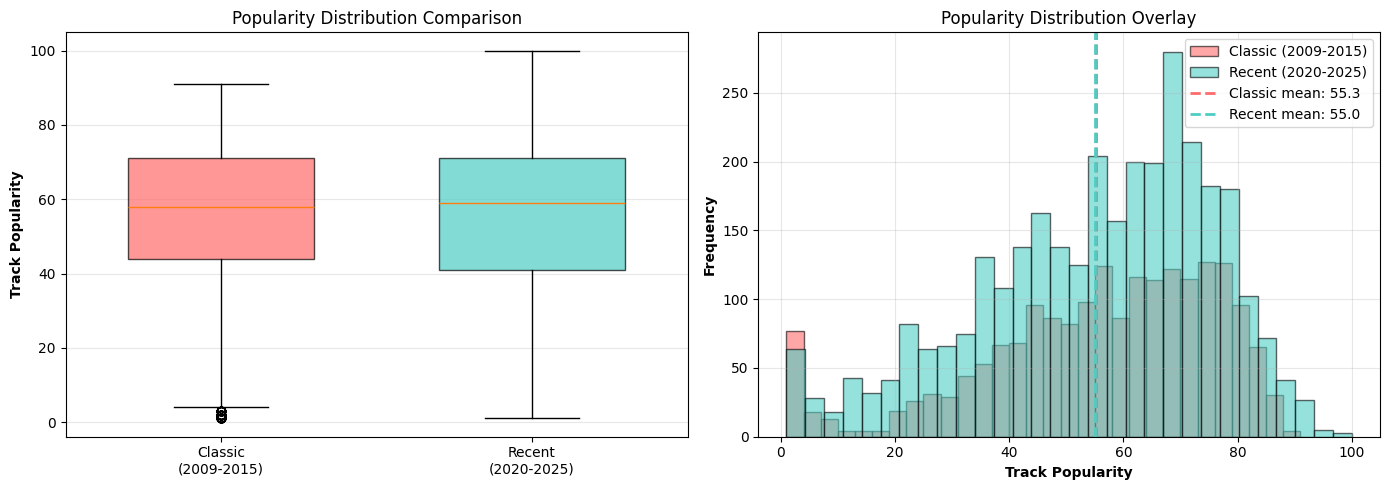

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

box_data = [q5_classic['track_popularity'], q5_recent['track_popularity']]
bp = axes[0].boxplot(box_data, labels=['Classic\n(2009-2015)', 'Recent\n(2020-2025)'],
                      patch_artist=True, widths=0.6)

colors = ['#FF6B6B', '#4ECDC4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_ylabel('Track Popularity', fontweight='bold')
axes[0].set_title('Popularity Distribution Comparison')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(q5_classic['track_popularity'], bins=30, alpha=0.6, 
             label='Classic (2009-2015)', color='#FF6B6B', edgecolor='black')
axes[1].hist(q5_recent['track_popularity'], bins=30, alpha=0.6, 
             label='Recent (2020-2025)', color='#4ECDC4', edgecolor='black')

axes[1].axvline(q5_classic['track_popularity'].mean(), color='#FF6B6B', 
                linestyle='--', linewidth=2, label=f"Classic mean: {q5_classic['track_popularity'].mean():.1f}")
axes[1].axvline(q5_recent['track_popularity'].mean(), color='#4ECDC4', 
                linestyle='--', linewidth=2, label=f"Recent mean: {q5_recent['track_popularity'].mean():.1f}")

axes[1].set_xlabel('Track Popularity', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Popularity Distribution Overlay')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**H0:** Dữ liệu độ phổ biến của bài hát tuân theo phân phối chuẩn.

$$H_0: X \sim N(\mu, \sigma^2)$$

**H1:** Dữ liệu độ phổ biến của bài hát không tuân theo phân phối chuẩn.

$$H_1: X \nsim N(\mu, \sigma^2)$$

In [32]:
groups_q5 = {
    'Cổ Điển (2009-2015)': q5_classic['track_popularity'],
    'Gần Đây (2020-2025)': q5_recent['track_popularity']
}

for name, data in groups_q5.items():
    print(f"{name} (n={len(data)}):")
    print(f"  Trung bình: {data.mean():.2f}, Trung vị: {data.median():.2f}")
    print(f"  Độ lệch: {data.skew():.3f}, Độ nhọn: {data.kurtosis():.3f}")
    
    if len(data) <= 5000:
        stat_sw, p_sw = shapiro(data)
        print(f"  Shapiro-Wilk: W={stat_sw:.4f}, giá trị p={p_sw:.4e}")
        print(f"  Kết quả: {'Không phân phối chuẩn' if p_sw < 0.05 else 'Phân phối chuẩn'}\n")

Cổ Điển (2009-2015) (n=1944):
  Trung bình: 55.29, Trung vị: 58.00
  Độ lệch: -0.850, Độ nhọn: 0.282
  Shapiro-Wilk: W=0.9357, giá trị p=3.4071e-28
  Kết quả: Không phân phối chuẩn

Gần Đây (2020-2025) (n=3182):
  Trung bình: 55.01, Trung vị: 59.00
  Độ lệch: -0.601, Độ nhọn: -0.249
  Shapiro-Wilk: W=0.9636, giá trị p=1.2972e-27
  Kết quả: Không phân phối chuẩn



**Kết luận:**
- Cả 2 nhóm đều KHÔNG tuân theo phân phối chuẩn (p < 0.05)
- Nên sử dụng Mann-Whitney U test (non-parametric)

**H0:** Phân phối độ phổ biến của bài hát Cổ Điển (2009-2015) và bài hát Gần Đây (2020-2025) là giống nhau.

$$H_0: F_{classic}(x) = F_{recent}(x)$$

**H1:** Phân phối độ phổ biến của bài hát Cổ Điển và bài hát Gần Đây là khác nhau.

$$H_1: F_{classic}(x) \neq F_{recent}(x)$$

In [33]:
classic_data = q5_classic['track_popularity'].dropna()
recent_data = q5_recent['track_popularity'].dropna()

print("Kiểm Định Mann-Whitney U:\n")

u_stat, p_value = mannwhitneyu(classic_data, recent_data, alternative='two-sided')
print(f"Giá trị U: {u_stat:.4f}")
print(f"Giá trị P: {p_value:.4e}")

if p_value < 0.05:
    print(f"Kết quả: Có sự khác biệt có ý nghĩa (p < 0.05)")
    print(f"Trung bình Cổ Điển: {classic_data.mean():.2f}")
    print(f"Trung bình Gần Đây: {recent_data.mean():.2f}")
else:
    print("Kết quả: Không có sự khác biệt có ý nghĩa")

Kiểm Định Mann-Whitney U:

Giá trị U: 3137379.0000
Giá trị P: 3.8692e-01
Kết quả: Không có sự khác biệt có ý nghĩa


### C. Kết quả & Giải thích

**Câu trả lời:** Bài hát kinh điển (2009-2015) và Bài hát gần đây (2020-2025) có độ phổ biến gần như tương đương - không có sự khác biệt đáng kể.

**Phát hiện chính:**
- Độ phổ biến trung bình gần như giống hệt nhau: Kinh điển 55.3 so với Gần đây 55.0 (chỉ chênh 0.28 điểm). 
- Tuy nhiên, biểu đồ hộp cũng cho thấy rằng các bài hát gần đây thường có độ phổ biến lớn nhất (các bài hit) cao hơn rõ rệt so với các bài hát cũ.

**Ý nghĩa thực tiễn:**
Các bài hát kinh điển đã vượt qua thử thách của thời gian - những bài từ 2009-2015 vẫn duy trì độ phổ biến tương đương với các phát hành gần đây. Điều này gợi ý nghệ sĩ nên tiếp tục khai thác lại kho nhạc cũ (remaster, live, TikTok trend…) bởi mức độ phổ biến trong dài hạn vẫn được duy trì mạnh mẽ.

**Hạn chế:**
Tập dữ liệu không phân biệt được liệu các bài hát cũ duy trì độ phổ biến do nghe tự nhiên hay do xu hướng hoài cổ. 

---

## 4.9 Câu hỏi 6: Đặc trưng quan trọng theo từng phân khúc

### Question

Những đặc trưng nào (features) quan trọng nhất thay đổi theo từng cụm (segment) độ nổi tiếng? Liệu mỗi phân khúc popularity có các yếu tố quyết định riêng biệt không?

### A. Tiền xử lý

Chia các bài hát thành 5 phân khúc dựa trên độ phổ biến, sau đó huấn luyện mô hình Random Forest cho từng phân khúc để trích xuất tầm quan trọng của đặc trưng.

In [34]:
q6_df = df.copy()

q6_df['explicit_encoded'] = q6_df['explicit'].astype(int)

album_dummies = pd.get_dummies(q6_df['album_type'], prefix='album', drop_first=False)
q6_df = pd.concat([q6_df, album_dummies], axis=1)

def count_genres(genre_str):
    if pd.isna(genre_str) or genre_str == '[]':
        return 0
    try:
        genres = ast.literal_eval(genre_str)
        return len(genres) if isinstance(genres, list) else 0
    except:
        return 0

q6_df['num_genres'] = q6_df['artist_genres'].apply(count_genres)

q6_df['popularity_segment'] = pd.cut(q6_df['track_popularity'], 
                                      bins=[0, 20, 40, 60, 80, 100],
                                      labels=['Very Low (0-20)', 'Low (20-40)', 'Medium (40-60)', 
                                              'High (60-80)', 'Very High (80-100)'])

q6_df = q6_df.dropna(subset=['num_genres'])

print(f'Segment distribution:')
print(q6_df['popularity_segment'].value_counts().sort_index())

Segment distribution:
popularity_segment
Very Low (0-20)        578
Low (20-40)           1269
Medium (40-60)        2391
High (60-80)          3396
Very High (80-100)     619
Name: count, dtype: int64


### B. Phân tích

**Phương pháp phân tích:**

Sử dụng các mô hình Random Forest cụ thể cho từng phân khúc để xác định tầm quan trọng của đặc trưng cho mỗi cấp độ phổ biến:

1. **Huấn luyện các mô hình RF riêng biệt**: Một mô hình cho mỗi phân khúc (tổng cộng 5 phân khúc) để nắm bắt các mô hình cụ thể của phân khúc
2. **Trích xuất tầm quan trọng của đặc trưng**: Sử dụng feature_importances_ tích hợp của RF để xếp hạng các đặc trưng theo đóng góp
3. **So sánh giữa các phân khúc**: Trực quan hóa sự thay đổi tầm quan trọng của đặc trưng qua các cấp độ phổ biến

**Các đặc trưng được phân tích:**
- `artist_popularity`: Độ nổi tiếng nghệ sĩ
- `artist_followers`: Quy mô lượng người hâm mộ
- `explicit_encoded`: Xếp hạng nội dung (0/1)
- `album_type_encoded`: Chiến lược phát hành (0/1/2)
- `num_genres`: Sự đa dạng thể loại
- `duration_min`: Độ dài bài hát

**Kết quả mong đợi:**
- Bảng tầm quan trọng của đặc trưng cho mỗi phân khúc
- Biểu đồ nhiệt hiển thị sự biến đổi tầm quan trọng qua các phân khúc
- Biểu đồ cột so sánh các đặc trưng hàng đầu mỗi phân khúc

**Lý do:** Các mức độ phổ biến khác nhau có thể yêu cầu các yếu tố thành công khác nhau - các bài hát ngách (độ phổ biến thấp) có thể dựa vào thời lượng/chất lượng, trong khi các bản hit lan truyền (độ phổ biến cao) yêu cầu danh tiếng nghệ sĩ.

In [35]:
q6_features = ['artist_popularity', 'artist_followers', 'explicit_encoded', 
               'album_album', 'album_compilation', 'album_single',
               'num_genres', 'duration_min'] 
q6_target = 'track_popularity'

q6_importance_results = {}
q6_r2_scores = {}

for segment in q6_df['popularity_segment'].unique():
    segment_data = q6_df[q6_df['popularity_segment'] == segment]
    
    if len(segment_data) < 50:
        continue
    
    X = segment_data[q6_features]
    y = segment_data[q6_target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    importances = pd.Series(rf.feature_importances_, index=q6_features)
    q6_importance_results[segment] = importances
    q6_r2_scores[segment] = rf.score(X_test, y_test)

q6_importance_df = pd.DataFrame(q6_importance_results).T
q6_importance_df

,artist_popularity,artist_followers,explicit_encoded,album_album,album_compilation,album_single,num_genres,duration_min
High (60-80),0.180561,0.289706,0.029723,0.017853,0.008431,0.012508,0.058058,0.403161
Medium (40-60),0.216273,0.323634,0.026759,0.013800,0.022661,0.016172,0.051397,0.329303
Low (20-40),0.230357,0.293139,0.020547,0.017550,0.014129,0.012958,0.052149,0.359172
Very High (80-100),0.223551,0.353872,0.025775,0.012094,0.000205,0.016775,0.039986,0.327741
Very Low (0-20),0.418353,0.209818,0.015907,0.015753,0.032955,0.022675,0.065813,0.218726


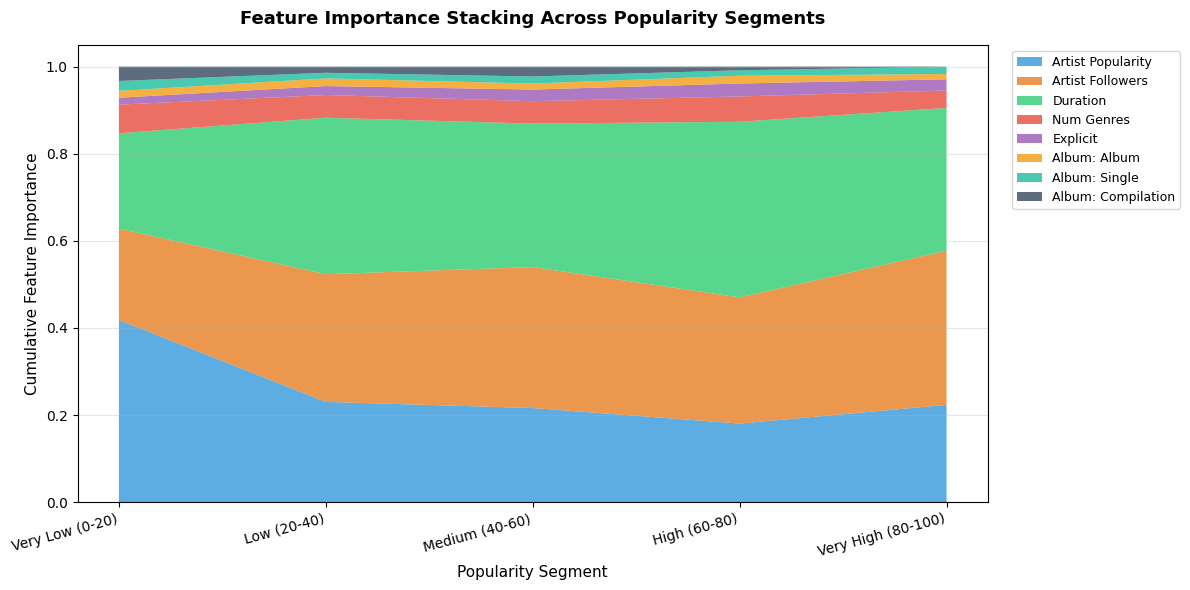

In [36]:
segments_order = ['Very Low (0-20)', 'Low (20-40)', 'Medium (40-60)', 
                  'High (60-80)', 'Very High (80-100)']

q6_plot_df = q6_importance_df.loc[segments_order]

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#34495e']

ax.stackplot(range(len(segments_order)), 
             q6_plot_df['artist_popularity'],
             q6_plot_df['artist_followers'],
             q6_plot_df['duration_min'],
             q6_plot_df['num_genres'],
             q6_plot_df['explicit_encoded'],
             q6_plot_df['album_album'],
             q6_plot_df['album_single'],
             q6_plot_df['album_compilation'],
             labels=['Artist Popularity', 'Artist Followers', 'Duration', 'Num Genres', 
                     'Explicit', 'Album: Album', 'Album: Single', 'Album: Compilation'],
             colors=colors,
             alpha=0.8)

ax.set_xticks(range(len(segments_order)))
ax.set_xticklabels(segments_order, rotation=15, ha='right')
ax.set_ylabel('Cumulative Feature Importance', fontsize=11)
ax.set_xlabel('Popularity Segment', fontsize=11)
ax.set_title('Feature Importance Stacking Across Popularity Segments', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q6_feature_importance_stacked.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

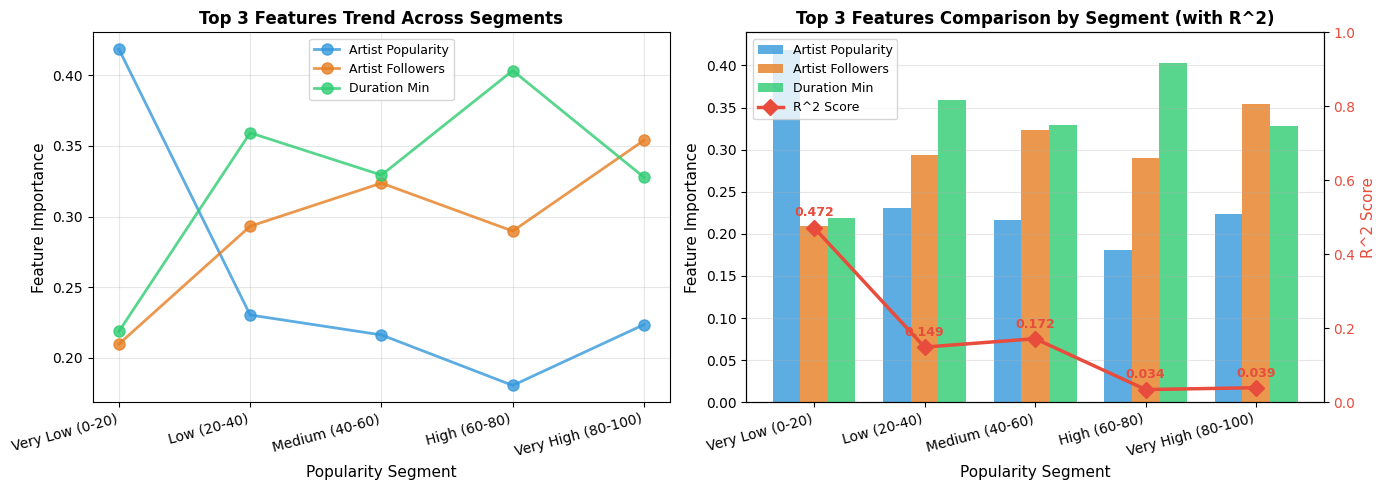

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_features = ['artist_popularity', 'artist_followers', 'duration_min']
colors_map = {'artist_popularity': '#3498db', 
              'artist_followers': '#e67e22', 
              'duration_min': '#2ecc71'}

for feature in top_features:
    axes[0].plot(range(len(segments_order)), q6_plot_df[feature], 
                 marker='o', linewidth=2, markersize=8, 
                 label=feature.replace('_', ' ').title(), 
                 color=colors_map[feature], alpha=0.8)

axes[0].set_xticks(range(len(segments_order)))
axes[0].set_xticklabels(segments_order, rotation=15, ha='right')
axes[0].set_ylabel('Feature Importance', fontsize=11)
axes[0].set_xlabel('Popularity Segment', fontsize=11)
axes[0].set_title('Top 3 Features Trend Across Segments', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='both', alpha=0.3)

x_pos = np.arange(len(segments_order))
width = 0.25

for idx, feature in enumerate(top_features):
    axes[1].bar(x_pos + idx * width, q6_plot_df[feature], width, 
                label=feature.replace('_', ' ').title(), 
                color=colors_map[feature], alpha=0.8)

r2_values = [q6_r2_scores[seg] for seg in segments_order]
ax2 = axes[1].twinx()
ax2.plot(x_pos + width, r2_values, color='#e74c3c', marker='D', linewidth=2.5, 
         markersize=8, label='R^2 Score', zorder=10)
ax2.set_ylabel('R^2 Score', fontsize=11, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.set_ylim(0, 1)

for i, r2 in enumerate(r2_values):
    ax2.text(x_pos[i] + width, r2 + 0.03, f'{r2:.3f}', 
             ha='center', fontsize=9, color='#e74c3c', fontweight='bold')

axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(segments_order, rotation=15, ha='right')
axes[1].set_ylabel('Feature Importance', fontsize=11)
axes[1].set_xlabel('Popularity Segment', fontsize=11)
axes[1].set_title('Top 3 Features Comparison by Segment (with R^2)', fontsize=12, fontweight='bold')

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q6_top_features_comparison.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

### C. Kết quả & Giải thích

**Câu trả lời:** Mỗi phân khúc độ phổ biến có các yếu tố thành công hoàn toàn khác nhau - không có công thức chung.

**Phát hiện chính:**

Phân khúc Rất thấp (0-20): Artist_popularity chiếm 42% tầm quan trọng. Mô hình đạt R^2=0.472, nghĩa là độ phổ biến ở cấp độ này khá dễ dự đoán - nếu nghệ sĩ không nổi thì bài hát cũng khó lên.

Phân khúc Trung bình (20-60): Duration_min (33-36%) và artist_followers (29-32%) trở thành yếu tố chính. R^2 giảm xuống 0.15-0.17, cho thấy đây là vùng cạnh tranh với nhiều yếu tố khác ảnh hưởng.

Phân khúc Cao và Rất cao (60-100): Artist_followers lên top (29-35%), duration_min vẫn mạnh (33-40%). Quan trọng nhất: R2 sụt xuống chỉ còn 0.031-0.039 - gần như không thể dự đoán được độ phổ biến ở cấp độ này với dữ liệu hiện có.

**Thông tin quan trọng về R2:** Mô hình giảm dần từ 0.472 xuống 0.039 chứng tỏ càng lên cao, thành công càng khó đoán. Cần khoảnh khắc lan truyền, chiến dịch tiếp thị, thời điểm may mắn mà dữ liệu không có.

**Ý nghĩa thực tiễn:**

Nghệ sĩ mới (Rất thấp): Tập trung xây dựng artist_popularity trước, hợp tác, chạy danh sách phát.

Nghệ sĩ tầm trung: Tối ưu hóa thời lượng và tăng lượng người theo dõi, chất lượng.

Nghệ sĩ đã thành danh muốn lên top: Nền tảng tốt là cần nhưng không đủ, phải chấp nhận yếu tố may mắn, vì R2=0.03 nghĩa là 97% phương sai không giải thích được bởi dữ liệu.

**Hạn chế:**

R2 thấp ở các phân khúc cao cho thấy thiếu các đặc trưng quan trọng như ngân sách tiếp thị, vị trí danh sách phát, yếu tố lan truyền. Kích thước mẫu nhỏ ở các phân khúc cực đoan có thể ảnh hưởng độ tin cậy.

---

## 4.10 Câu hỏi 7: Machine Learning - Dự đoán Track Popularity

### Question

Xây dựng models để predict track popularity. So sánh performance của các algorithms khác nhau (Linear Regression, XGBoost, Random Forest, Gradient Boosting, Extra Trees, LightGBM) để tìm model tốt nhất.

### A. Tiền xử lý

**Feature Engineering:**
- Mã hóa one-hot cho `album_type` (album, compilation, single) để tránh thiên kiến thứ tự
- Encode `explicit` thành 0/1
- Tính số lượng thể loại của artist (`num_genres`)
- Tính tổng số bài hát của artist (`artist_total_tracks`)
- Tính số bài hát explicit của artist (`explicit_per_artist`)

**Features cuối cùng:** artist_popularity, artist_followers, explicit_encoded, album_album, album_compilation, album_single, duration_min, num_genres, artist_total_tracks, album_total_tracks, explicit_per_artist

**Train/Test Split:** 80/20 với random_state=42

**Scaling:**
- MinMaxScaler cho `artist_popularity` (giữ phạm vi 0-100 tương đối)
- StandardScaler cho các features còn lại (chuẩn hóa về mean=0, std=1)

In [38]:
q7_df = df.copy()

q7_df['explicit_encoded'] = q7_df['explicit'].astype(int)

album_dummies = pd.get_dummies(q7_df['album_type'], prefix='album', drop_first=False)
q7_df = pd.concat([q7_df, album_dummies], axis=1)

def count_genres(genre_str):
    if pd.isna(genre_str) or genre_str == '[]':
        return 0
    try:
        genres = ast.literal_eval(genre_str)
        return len(genres) if isinstance(genres, list) else 0
    except:
        return 0

q7_df['num_genres'] = q7_df['artist_genres'].apply(count_genres)
q7_df = q7_df.dropna(subset=['num_genres'])

artist_track_count = q7_df.groupby('artist_name')['track_id'].count().reset_index()
artist_track_count.columns = ['artist_name', 'artist_total_tracks']

explicit_per_artist = q7_df.groupby('artist_name')['explicit_encoded'].sum().reset_index()
explicit_per_artist.columns = ['artist_name', 'explicit_per_artist']

q7_df = q7_df.merge(artist_track_count, on='artist_name', how='left')
q7_df = q7_df.merge(explicit_per_artist, on='artist_name', how='left')

q7_df['random_gaussian'] = np.random.normal(0, 1, size=len(q7_df))

q7_features = ['artist_popularity', 'artist_followers', 'explicit_encoded',
               'album_album', 'album_compilation', 'album_single', 
               'duration_min', 'num_genres', 'artist_total_tracks', 
               'album_total_tracks', 'explicit_per_artist'] 
               
q7_target = 'track_popularity'

X = q7_df[q7_features]
y = q7_df[q7_target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

artist_pop_train = X_train[['artist_popularity']].copy()
artist_pop_test = X_test[['artist_popularity']].copy()

other_features = [col for col in X_train.columns if col != 'artist_popularity']
X_train_other = X_train[other_features].copy()
X_test_other = X_test[other_features].copy()

minmax_scaler = MinMaxScaler()
artist_pop_train_scaled = minmax_scaler.fit_transform(artist_pop_train)
artist_pop_test_scaled = minmax_scaler.transform(artist_pop_test)

scaler = StandardScaler()
X_train_other_scaled = scaler.fit_transform(X_train_other)
X_test_other_scaled = scaler.transform(X_test_other)

X_train_scaled = pd.DataFrame(X_train_other_scaled, columns=other_features, index=X_train.index)
X_train_scaled['artist_popularity'] = artist_pop_train_scaled

X_test_scaled = pd.DataFrame(X_test_other_scaled, columns=other_features, index=X_test.index)
X_test_scaled['artist_popularity'] = artist_pop_test_scaled

X_train = X_train_scaled[X.columns]
X_test = X_test_scaled[X.columns]

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (7017, 11)
X_test shape: (1755, 11)
y_train shape: (7017,)
y_test shape: (1755,)


### B. Phân tích

**Phương pháp phân tích:**

So sánh hiệu suất của 6 thuật toán ML trên tác vụ dự đoán độ phổ biến bài hát:

1. **Hồi quy tuyến tính (Linear Regression)** (cơ sở): Mô hình đơn giản để thiết lập hiệu suất cơ sở. Giả định mối quan hệ tuyến tính giữa các đặc trưng và mục tiêu.

2. **XGBoost**: Extreme Gradient Boosting, một thuật toán boosting mạnh mẽ với regularization tích hợp.

3. **Rừng ngẫu nhiên (Random Forest)**: Tập hợp các cây quyết định với kỹ thuật bagging.

4. **Gradient Boosting**: Tập hợp tuần tự, mỗi cây học từ lỗi của cây trước.

5. **Extra Trees**: Tương tự Random Forest nhưng phân chia các nút ngẫu nhiên thay vì tìm phân chia tốt nhất.

6. **LightGBM**: Gradient boosting được tối ưu hóa cho tốc độ và hiệu quả bộ nhớ.

**Quy trình làm việc:**

**Approach 1: Train toàn bộ dữ liệu**
- Chia dữ liệu 80/20 train/test với random_state=42 để tái lập
- Huấn luyện 6 mô hình với 10-fold cross-validation
- Đánh giá trên tập kiểm tra với 3 chỉ số: R^2 score, MAE, RMSE
- Kết hợp các mô hình bằng Ensemble (Simple Average và Weighted Average)

**Approach 2: Clustering-based models**
- Áp dụng K-Means clustering (K=3) trên toàn bộ dữ liệu để phân chia thành các nhóm đặc trưng
- Huấn luyện mô hình riêng cho từng cluster, giả định mỗi nhóm có mối quan hệ dự đoán khác biệt
- So sánh với approach train chung để đánh giá hiệu quả của phân cụm

**Kết quả mong đợi:**
- Bảng so sánh các chỉ số giữa các mô hình và approaches
- Biểu đồ cột so sánh R^2/MAE/RMSE giữa các mô hình
- Biểu đồ phân tán: thực tế so với dự đoán (mô hình tốt nhất)
- Biểu đồ tầm quan trọng của đặc trưng (các mô hình dựa trên cây)
- Visualization PCA 2D/3D để quan sát phân bố clusters

In [39]:
SEED = 422
N_FOLDS = 10

model_configs = {
    'Linear Regression': {
        'class': LinearRegression,
        'params': {}
    },
    'XGBoost': {
        'class': XGBRegressor,
        'params': {'n_estimators': 100, 'max_depth': 4, 'random_state': SEED, 'n_jobs': -1, 'verbosity': 0}
    },
    'Random Forest': {
        'class': RandomForestRegressor,
        'params': {'n_estimators': 100, 'max_depth': 10, 'random_state': SEED, 'n_jobs': -1}
    },
    'Gradient Boosting': {
        'class': GradientBoostingRegressor,
        'params': {'n_estimators': 70, 'max_depth': 5, 'random_state': SEED}
    },
    'Extra Trees': {
        'class': ExtraTreesRegressor,
        'params': {'n_estimators': 50, 'max_depth':15, 'random_state': SEED, 'n_jobs': -1}
    },
    'LightGBM': {
        'class': lgb.LGBMRegressor,
        'params': {'n_estimators': 100, 'max_depth': 5, 'random_state': SEED, 'verbose': -1}
    }
}

q7_results = {}
q7_metrics_data = []

print(f'Training với {len(X_train):,} samples (train) + {len(X_test):,} hold-out test')
print(f'Sử dụng {N_FOLDS}-fold CV trên training set với seed={SEED}')
print(f'Target mean: {y_train.mean():.2f}, std: {y_train.std():.2f}')
print(f'Test target mean: {y_test.mean():.2f}, std: {y_test.std():.2f}\n')

for name, config in model_configs.items():
    print(f'Training {name}', end=' ')
    
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    val_r2_scores = []
    val_mae_scores = []
    val_rmse_scores = []
    
    # K-Fold CV với cùng hyperparameters
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Tạo model instance với cùng config
        fold_model = config['class'](**config['params'])
        fold_model.fit(X_fold_train, y_fold_train)
        y_val_pred = fold_model.predict(X_fold_val)
        
        val_r2_scores.append(r2_score(y_fold_val, y_val_pred))
        val_mae_scores.append(mean_absolute_error(y_fold_val, y_val_pred))
        val_rmse_scores.append(np.sqrt(mean_squared_error(y_fold_val, y_val_pred)))
    
    avg_val_r2 = np.mean(val_r2_scores)
    std_val_r2 = np.std(val_r2_scores)
    avg_val_mae = np.mean(val_mae_scores)
    avg_val_rmse = np.mean(val_rmse_scores)
    
    print(f'Val R2: {avg_val_r2:.2f} (std: {std_val_r2:.2f})')
    
    # Train trên toàn bộ train set với cùng hyperparameters
    final_model = config['class'](**config['params'])
    final_model.fit(X_train, y_train)
    y_test_pred = final_model.predict(X_test)
    
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    q7_results[name] = {
        'model': final_model,
        'predictions': y_test_pred
    }
    
    q7_metrics_data.append({
        'Model': name,
        f'Val R^2 ({N_FOLDS}-fold)': avg_val_r2,
        'Val R^2 Std': std_val_r2,
        f'Val MAE ({N_FOLDS}-fold)': avg_val_mae,
        f'Val RMSE ({N_FOLDS}-fold)': avg_val_rmse,
        'Test R^2': test_r2,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse
    })

q7_metrics_df = pd.DataFrame(q7_metrics_data).set_index('Model')
q7_metrics_df

Training với 7,017 samples (train) + 1,755 hold-out test
Sử dụng 10-fold CV trên training set với seed=422
Target mean: 52.31, std: 24.05
Test target mean: 51.96, std: 24.14

Training Linear Regression Val R2: 0.25 (std: 0.03)
Training XGBoost Val R2: 0.31 (std: 0.03)
Training Random Forest Val R2: 0.33 (std: 0.03)
Training Gradient Boosting Val R2: 0.32 (std: 0.03)
Training Extra Trees Val R2: 0.32 (std: 0.04)
Training LightGBM Val R2: 0.32 (std: 0.03)


,Val R^2 (10-fold),Val R^2 Std,Val MAE (10-fold),Val RMSE (10-fold),Test R^2,Test MAE,Test RMSE
Model,,,,,,,
Linear Regression,0.247905,0.027522,15.590526,20.834189,0.266076,15.492175,20.674076
XGBoost,0.305837,0.026445,14.344764,20.015406,0.335108,14.191945,19.677780
Random Forest,0.326508,0.028958,14.198489,19.715141,0.351970,14.080961,19.426658
Gradient Boosting,0.320680,0.026713,14.337259,19.800271,0.348077,14.119382,19.484922
Extra Trees,0.316147,0.041134,13.971972,19.861647,0.337142,13.885328,19.647661
LightGBM,0.319573,0.028751,14.305053,19.815313,0.350530,14.086811,19.448228


Kết hợp predictions của các mô hình bằng Simple Average và Weighted Average (dựa trên Val R^2) để cải thiện độ chính xác dự đoán.

In [ ]:
# Lấy predictions của tất cả models
all_predictions = np.array([q7_results[name]['predictions'] for name in model_configs.keys()])

# Method 1: Simple Average (Equal Weight)
ensemble_pred_avg = np.mean(all_predictions, axis=0)

test_r2_avg = r2_score(y_test, ensemble_pred_avg)
test_mae_avg = mean_absolute_error(y_test, ensemble_pred_avg)
test_rmse_avg = np.sqrt(mean_squared_error(y_test, ensemble_pred_avg))

# Method 2: Weighted Average (dựa trên Validation R^2 scores)
val_r2_scores = [q7_metrics_df.loc[name, f'Val R^2 ({N_FOLDS}-fold)'] for name in model_configs.keys()]
# Chuyển negative R^2 thành 0 để tránh weight âm
val_r2_scores = np.maximum(val_r2_scores, 0)
weights = np.array(val_r2_scores) / np.sum(val_r2_scores)

ensemble_pred_weighted = np.average(all_predictions, axis=0, weights=weights)

test_r2_weighted = r2_score(y_test, ensemble_pred_weighted)
test_mae_weighted = mean_absolute_error(y_test, ensemble_pred_weighted)
test_rmse_weighted = np.sqrt(mean_squared_error(y_test, ensemble_pred_weighted))

# Thêm vào metrics dataframe
ensemble_metrics = pd.DataFrame([
    {
        'Model': 'Ensemble (Simple Avg)',
        f'Val R^2 ({N_FOLDS}-fold)': np.nan,
        'Val R^2 Std': np.nan,
        f'Val MAE ({N_FOLDS}-fold)': np.nan,
        f'Val RMSE ({N_FOLDS}-fold)': np.nan,
        'Test R^2': test_r2_avg,
        'Test MAE': test_mae_avg,
        'Test RMSE': test_rmse_avg
    },
    {
        'Model': 'Ensemble (Weighted Avg)',
        f'Val R^2 ({N_FOLDS}-fold)': np.nan,
        'Val R^2 Std': np.nan,
        f'Val MAE ({N_FOLDS}-fold)': np.nan,
        f'Val RMSE ({N_FOLDS}-fold)': np.nan,
        'Test R^2': test_r2_weighted,
        'Test MAE': test_mae_weighted,
        'Test RMSE': test_rmse_weighted
    }
]).set_index('Model')

q7_metrics_df_with_ensemble = pd.concat([q7_metrics_df, ensemble_metrics])

q7_metrics_df_with_ensemble

,Val R^2 (10-fold),Val R^2 Std,Val MAE (10-fold),Val RMSE (10-fold),Test R^2,Test MAE,Test RMSE
Model,,,,,,,
Linear Regression,0.247905,0.027522,15.590526,20.834189,0.266076,15.492175,20.674076
XGBoost,0.305837,0.026445,14.344764,20.015406,0.335108,14.191945,19.677780
Random Forest,0.326508,0.028958,14.198489,19.715141,0.351970,14.080961,19.426658
Gradient Boosting,0.320680,0.026713,14.337259,19.800271,0.348077,14.119382,19.484922
Extra Trees,0.316147,0.041134,13.971972,19.861647,0.337142,13.885328,19.647661
LightGBM,0.319573,0.028751,14.305053,19.815313,0.350530,14.086811,19.448228
Ensemble (Simple Avg),NaN,NaN,NaN,NaN,0.361574,14.035164,19.282167
Ensemble (Weighted Avg),NaN,NaN,NaN,NaN,0.362591,14.002097,19.266803


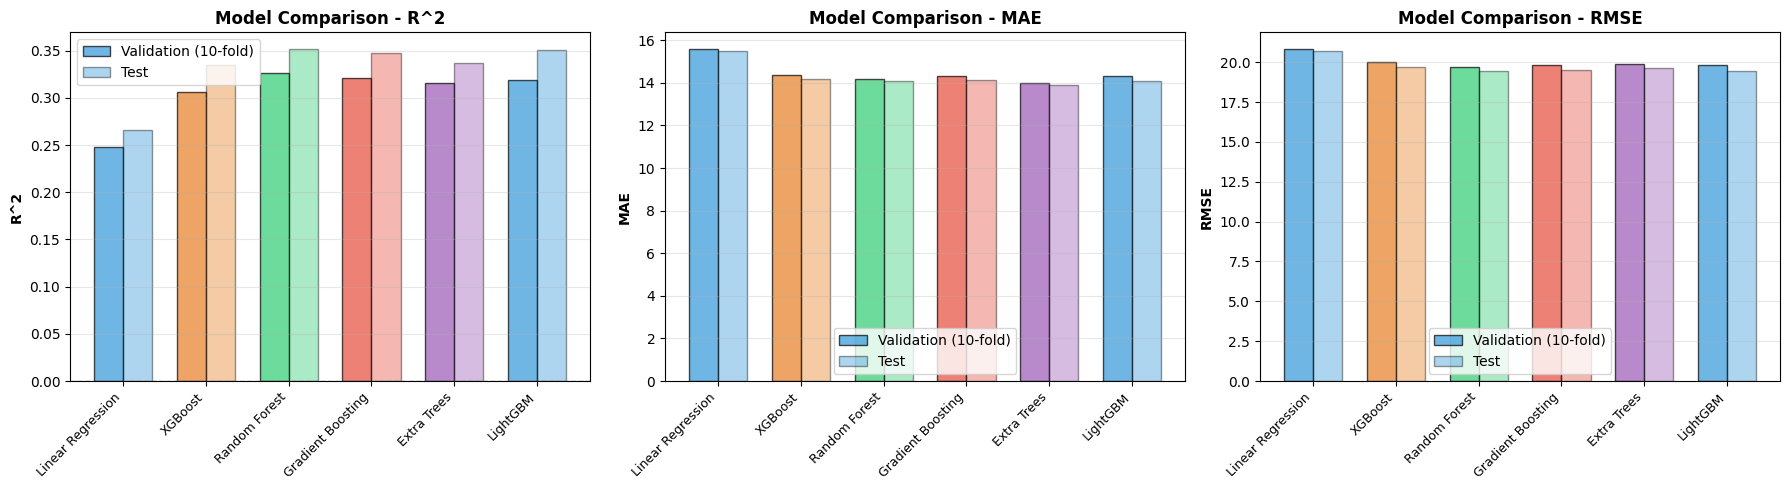

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['R^2', 'MAE', 'RMSE']
colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6']

for idx, metric in enumerate(metrics):
    val_col = f'Val {metric} ({N_FOLDS}-fold)'
    test_col = f'Test {metric}'
    
    x_pos = np.arange(len(q7_metrics_df))
    width = 0.35
    
    axes[idx].bar(x_pos - width/2, q7_metrics_df[val_col], width, 
                  label=f'Validation ({N_FOLDS}-fold)', color=colors, alpha=0.7, edgecolor='black')
    axes[idx].bar(x_pos + width/2, q7_metrics_df[test_col], width, 
                  label='Test', color=colors, alpha=0.4, edgecolor='black')
    
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(q7_metrics_df.index, rotation=45, ha='right', fontsize=9)
    axes[idx].set_ylabel(metric, fontweight='bold')
    axes[idx].set_title(f'Model Comparison - {metric}', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)
    
    if metric == 'R^2':
        axes[idx].axhline(y=0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('q7_model_comparison.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

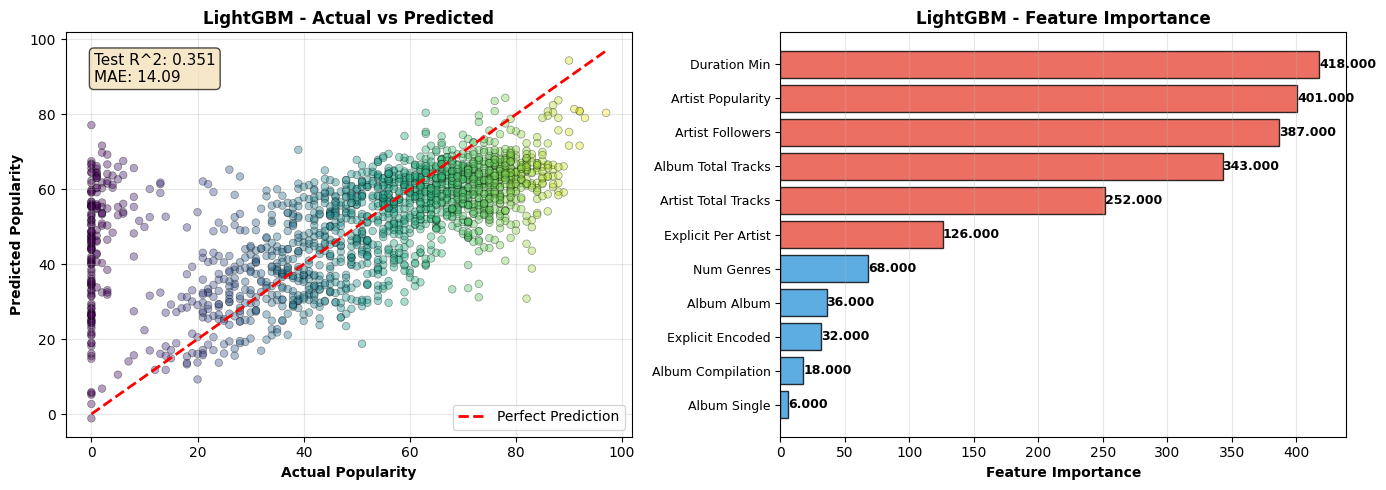

In [42]:
best_model_name = 'LightGBM'
best_model = q7_results[best_model_name]['model']
best_predictions = q7_results[best_model_name]['predictions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_predictions, alpha=0.4, s=30, c=y_test, cmap='viridis', edgecolors='black', linewidths=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')

axes[0].set_xlabel('Actual Popularity', fontweight='bold')
axes[0].set_ylabel('Predicted Popularity', fontweight='bold')
axes[0].set_title(f'{best_model_name} - Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

test_r2 = q7_metrics_df.loc[best_model_name, 'Test R^2']
test_mae = q7_metrics_df.loc[best_model_name, 'Test MAE']
axes[0].text(0.05, 0.95, f'Test R^2: {test_r2:.3f}\nMAE: {test_mae:.2f}', 
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

importances = pd.Series(best_model.feature_importances_, index=q7_features).sort_values(ascending=True)
colors_importance = ['#3498db' if x < importances.median() else '#e74c3c' for x in importances]

axes[1].barh(range(len(importances)), importances.values, color=colors_importance, alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(len(importances)))
axes[1].set_yticklabels([label.replace('_', ' ').title() for label in importances.index], fontsize=9)
axes[1].set_xlabel('Feature Importance', fontweight='bold')
axes[1].set_title(f'{best_model_name} - Feature Importance', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

for i, val in enumerate(importances.values):
    axes[1].text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('q7_best_model_analysis.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

Nhận thấy dữ liệu có thể có các nhóm đặc trưng khác nhau (ví dụ: các thể loại nhạc, nhóm độ tuổi người nghe), ta thử áp dụng K-Means clustering để phân chia dữ liệu thành các cụm, sau đó train mô hình riêng cho từng cụm nhằm cải thiện độ chính xác dự đoán.

In [43]:
# Gộp train và test để cluster (unsupervised learning)
from sklearn.mixture import GaussianMixture
X_full = pd.concat([X_train, X_test], axis=0)

# Thực hiện K-Means với K=3
SEED = 42
N_CLUSTERS = 3

print(f"Clustering trên toàn bộ dữ liệu: {len(X_full):,} samples")
print(f"  Train: {len(X_train):,} samples")
print(f"  Test:  {len(X_test):,} samples")
print(f"\nThực hiện K-Means clustering với K={N_CLUSTERS}...")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=50, init="k-means++")
cluster_labels_full = kmeans.fit_predict(X_full)

# Split cluster labels về train và test
cluster_labels_train = cluster_labels_full[:len(X_train)]
cluster_labels_test = cluster_labels_full[len(X_train):]

# Thống kê phân bố clusters
print(f"\nPhân bố clusters trong Training set:")
for i in range(N_CLUSTERS):
    count = np.sum(cluster_labels_train == i)
    percentage = count / len(cluster_labels_train) * 100
    print(f"  Cluster {i}: {count:,} samples ({percentage:.1f}%)")

print(f"\nPhân bố clusters trong Test set:")
for i in range(N_CLUSTERS):
    count = np.sum(cluster_labels_test == i)
    percentage = count / len(cluster_labels_test) * 100
    print(f"  Cluster {i}: {count:,} samples ({percentage:.1f}%)")

# Thêm cluster labels vào dataframe
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = cluster_labels_train
X_test_clustered = X_test.copy()
X_test_clustered['cluster'] = cluster_labels_test

Clustering trên toàn bộ dữ liệu: 8,772 samples
  Train: 7,017 samples
  Test:  1,755 samples

Thực hiện K-Means clustering với K=3...

Phân bố clusters trong Training set:
  Cluster 0: 4,525 samples (64.5%)
  Cluster 1: 1,793 samples (25.6%)
  Cluster 2: 699 samples (10.0%)

Phân bố clusters trong Test set:
  Cluster 0: 1,175 samples (67.0%)
  Cluster 1: 416 samples (23.7%)
  Cluster 2: 164 samples (9.3%)


In [44]:
# Gộp train và test để cluster (unsupervised learning)
from sklearn.mixture import GaussianMixture
X_full = pd.concat([X_train, X_test], axis=0)

# Thực hiện K-Means với K=3
SEED = 42
N_CLUSTERS = 3

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=50, init="k-means++")
cluster_labels_full = kmeans.fit_predict(X_full)

# Split cluster labels về train và test
cluster_labels_train = cluster_labels_full[:len(X_train)]
cluster_labels_test = cluster_labels_full[len(X_train):]

# Thêm cluster labels vào dataframe
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = cluster_labels_train
X_test_clustered = X_test.copy()
X_test_clustered['cluster'] = cluster_labels_test

# Tạo DataFrame thống kê phân bố clusters
cluster_stats = []
for i in range(N_CLUSTERS):
    train_count = np.sum(cluster_labels_train == i)
    test_count = np.sum(cluster_labels_test == i)
    train_pct = train_count / len(cluster_labels_train) * 100
    test_pct = test_count / len(cluster_labels_test) * 100
    cluster_stats.append({
        'Cluster': i,
        'Train Count': train_count,
        'Train %': f'{train_pct:.1f}%',
        'Test Count': test_count,
        'Test %': f'{test_pct:.1f}%'
    })

cluster_distribution = pd.DataFrame(cluster_stats)
cluster_distribution

,Cluster,Train Count,Train %,Test Count,Test %
0,0,4525,64.5%,1175,67.0%
1,1,1793,25.6%,416,23.7%
2,2,699,10.0%,164,9.3%


In [45]:
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_train)

pca_3d = PCA(n_components=3, random_state=SEED)
X_pca_3d = pca_3d.fit_transform(X_train)

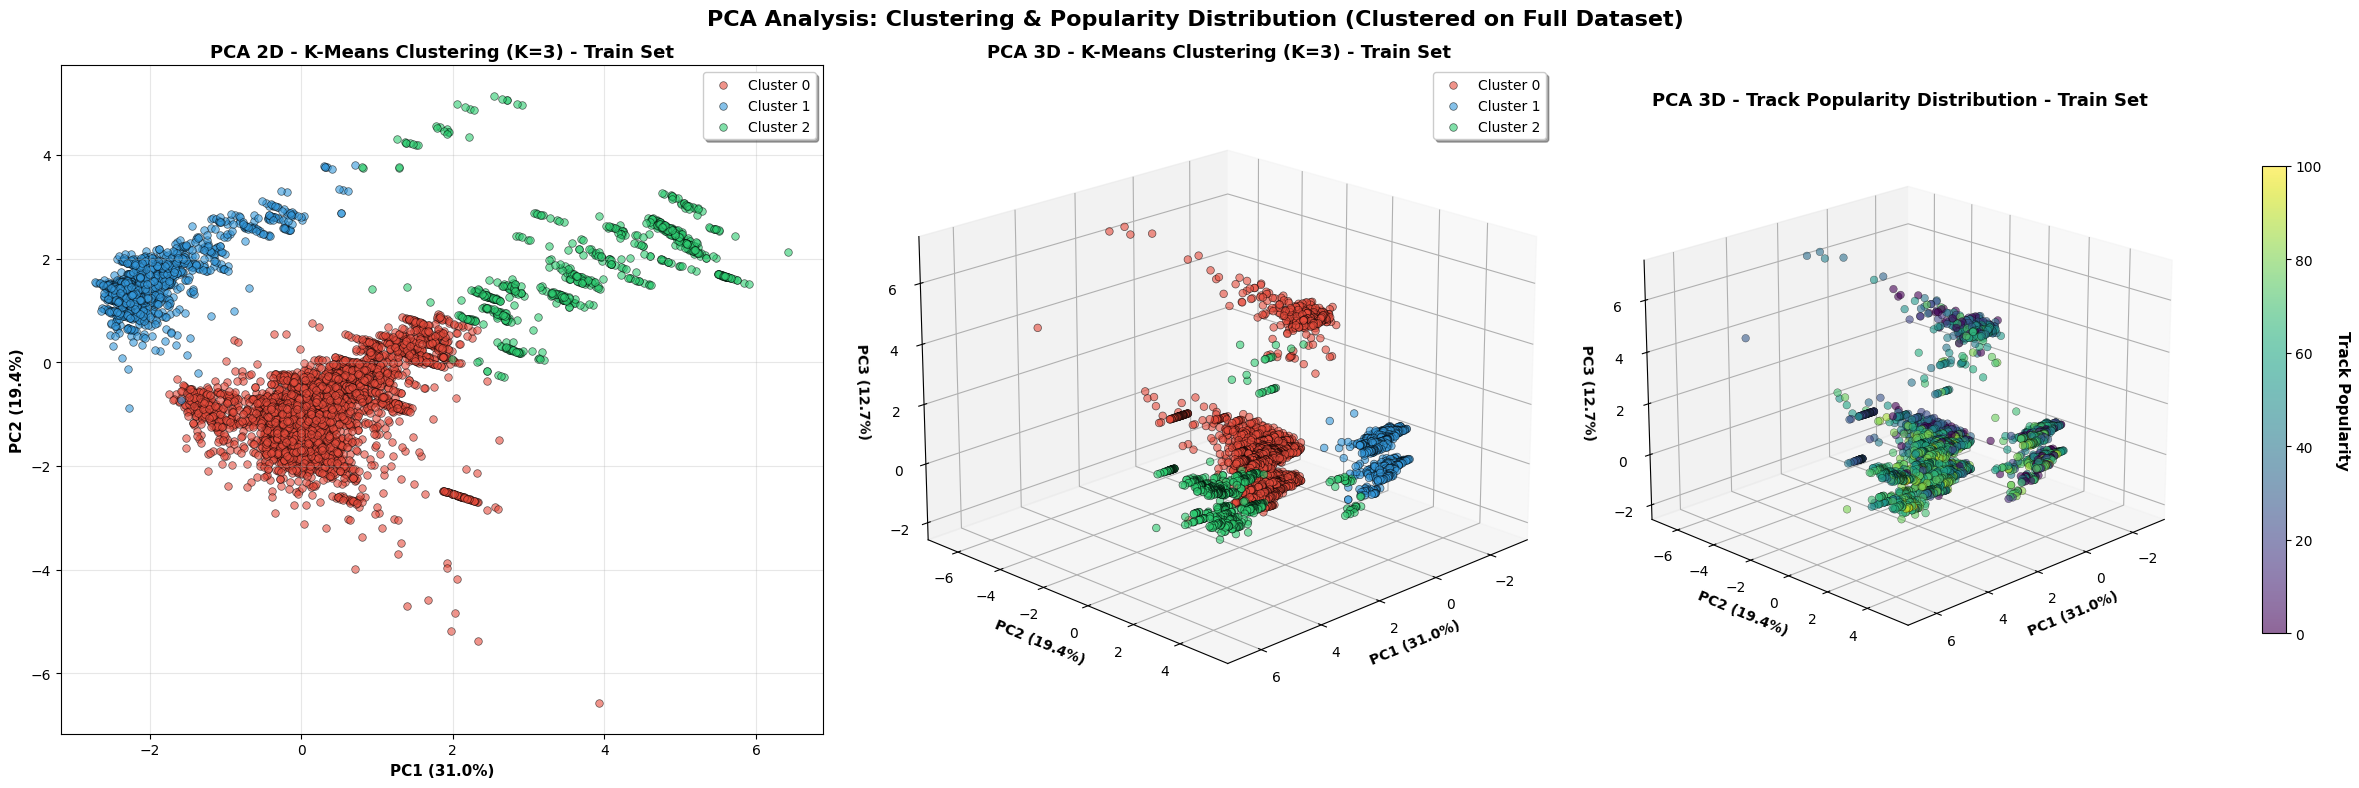

In [46]:
fig = plt.figure(figsize=(24, 8))

scatter_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
popularity_values = y_train.values

# PCA 2D với cluster colors
ax1 = fig.add_subplot(1, 3, 1)
for i in range(N_CLUSTERS):
    mask = cluster_labels_train == i
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                c=scatter_colors[i], label=f'Cluster {i}', 
                alpha=0.6, edgecolors='k', linewidth=0.5, s=30)

ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontweight='bold', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontweight='bold', fontsize=11)
ax1.set_title(f'PCA 2D - K-Means Clustering (K={N_CLUSTERS}) - Train Set', fontweight='bold', fontsize=13)
ax1.legend(loc='best', frameon=True, shadow=True)
ax1.grid(alpha=0.3)

# PCA 3D với cluster colors
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
for i in range(N_CLUSTERS):
    mask = cluster_labels_train == i
    ax2.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
                c=scatter_colors[i], label=f'Cluster {i}', 
                alpha=0.6, edgecolors='k', linewidth=0.5, s=30)

ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})', fontweight='bold', fontsize=10)
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})', fontweight='bold', fontsize=10)
ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})', fontweight='bold', fontsize=10)
ax2.set_title(f'PCA 3D - K-Means Clustering (K={N_CLUSTERS}) - Train Set', fontweight='bold', fontsize=13)
ax2.legend(loc='best', frameon=True, shadow=True)
ax2.view_init(elev=20, azim=45)
ax2.grid(alpha=0.3)

# PCA 3D với popularity colorbar
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
scatter = ax3.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                      c=popularity_values, cmap='viridis', alpha=0.6,
                      edgecolors='k', linewidth=0.3, s=30)

cbar = plt.colorbar(scatter, ax=ax3, pad=0.1, shrink=0.7)
cbar.set_label('Track Popularity', fontweight='bold', fontsize=11, rotation=270, labelpad=20)

ax3.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})', fontweight='bold', fontsize=10)
ax3.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})', fontweight='bold', fontsize=10)
ax3.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})', fontweight='bold', fontsize=10)
ax3.set_title('PCA 3D - Track Popularity Distribution - Train Set', fontweight='bold', fontsize=13)
ax3.view_init(elev=20, azim=45)
ax3.grid(alpha=0.3)

fig.suptitle(f'PCA Analysis: Clustering & Popularity Distribution (Clustered on Full Dataset)', 
             fontweight='bold', fontsize=16, y=0.98)

plt.tight_layout()
plt.savefig('pca_combined_visualization.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

In [ ]:
SEED = 422
N_FOLDS = 10

model_configs = {
    'Linear Regression': {'class': LinearRegression, 'params': {}},
    'XGBoost': {'class': XGBRegressor, 'params': {'n_estimators': 100, 'max_depth': 4, 'random_state': SEED, 'n_jobs': -1, 'verbosity': 0}},
    'Random Forest': {'class': RandomForestRegressor, 'params': {'n_estimators': 100, 'max_depth': 15, 'random_state': SEED, 'n_jobs': -1}},
    'Gradient Boosting': {'class': GradientBoostingRegressor, 'params': {'n_estimators': 70, 'max_depth': 5, 'random_state': SEED}},
    'Extra Trees': {'class': ExtraTreesRegressor, 'params': {'n_estimators': 100, 'max_depth': 35, 'random_state': SEED, 'n_jobs': -1}},
    'LightGBM': {'class': lgb.LGBMRegressor, 'params': {'n_estimators': 100, 'max_depth': 5, 'random_state': SEED, 'verbose': -1}}
}

cluster_models = {name: {} for name in model_configs.keys()}
all_predictions = {name: np.zeros(len(y_test)) for name in model_configs.keys()}
cluster_metrics_detail = []

for cluster_id in range(N_CLUSTERS):
    mask_train = cluster_labels_train == cluster_id
    mask_test = cluster_labels_test == cluster_id
    
    X_train_c = X_train[mask_train]
    y_train_c = y_train[mask_train]
    X_test_c = X_test[mask_test]
    y_test_c = y_test[mask_test]
    
    if len(X_train_c) < N_FOLDS * 2 or len(X_test_c) == 0:
        continue
    
    for name, cfg in model_configs.items():
        kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
        val_r2 = []
        
        for train_idx, val_idx in kf.split(X_train_c):
            X_fold_train = X_train_c.iloc[train_idx]
            y_fold_train = y_train_c.iloc[train_idx]
            X_fold_val = X_train_c.iloc[val_idx]
            y_fold_val = y_train_c.iloc[val_idx]
            
            fold_model = cfg['class'](**cfg['params'])
            fold_model.fit(X_fold_train, y_fold_train)
            y_fold_pred = fold_model.predict(X_fold_val)
            val_r2.append(r2_score(y_fold_val, y_fold_pred))
        
        model = cfg['class'](**cfg['params'])
        model.fit(X_train_c, y_train_c)
        y_pred_cluster = model.predict(X_test_c)
        
        cluster_models[name][cluster_id] = model
        all_predictions[name][mask_test] = y_pred_cluster
        
        test_r2_cluster = r2_score(y_test_c, y_pred_cluster)
        test_mae_cluster = mean_absolute_error(y_test_c, y_pred_cluster)
        test_rmse_cluster = np.sqrt(mean_squared_error(y_test_c, y_pred_cluster))
        
        cluster_metrics_detail.append({
            'Cluster': cluster_id,
            'Model': name,
            'Val R^2': np.mean(val_r2),
            'Val R^2 Std': np.std(val_r2),
            'Test R^2': test_r2_cluster,
            'Test MAE': test_mae_cluster,
            'Test RMSE': test_rmse_cluster,
            'N_train': len(X_train_c),
            'N_test': len(X_test_c)
        })

In [ ]:
# Tính metrics tổng thể cho từng model
clustered_metrics = []

for name in model_configs.keys():
    y_pred_full = all_predictions[name]
    
    # Overall test metrics
    test_r2 = r2_score(y_test, y_pred_full)
    test_mae = mean_absolute_error(y_test, y_pred_full)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_full))
    
    # Average validation metrics across clusters
    model_cluster_metrics = [m for m in cluster_metrics_detail if m['Model'] == name]
    avg_val_r2 = np.mean([m['Val R^2'] for m in model_cluster_metrics])
    avg_val_r2_std = np.mean([m['Val R^2 Std'] for m in model_cluster_metrics])
    
    clustered_metrics.append({
        'Model': name,
        f'Val R^2 ({N_FOLDS}-fold)': avg_val_r2,
        'Val R^2 Std': avg_val_r2_std,
        'Test R^2': test_r2,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse
    })

clustered_models_df = pd.DataFrame(clustered_metrics).set_index('Model')
clustered_models_df

,Val R² (10-fold),Val R² Std,Test R²,Test MAE,Test RMSE
Model,,,,,
Linear Regression,0.221482,0.081096,0.286321,15.130029,20.386943
XGBoost,0.165241,0.150458,0.306071,14.347340,20.102868
Random Forest,0.236906,0.113479,0.319923,14.075258,19.901211
Gradient Boosting,0.242225,0.105651,0.338730,14.136598,19.624111
Extra Trees,0.080667,0.197407,0.206184,14.693625,21.501098
LightGBM,0.275026,0.099287,0.342970,14.122009,19.561097


### C. Kết quả & Giải thích

**Câu trả lời:** Sau khi so sánh 6 mô hình khác nhau, **Random Forest, Gradient Boosting và LightGBM** là 3 mô hình tốt nhất với Test R^2 = 0.35, vượt trội hơn Linear Regression (0.27), XGBoost (0.34), và Extra Trees (0.34). Cụ thể, Random Forest đạt Test MAE thấp nhất (14.08), trong khi Gradient Boosting và LightGBM có Test MAE lần lượt là 14.12 và 14.09.

**Ensemble (Weighted Average)** kết hợp các mô hình đạt hiệu suất cao nhất với **Test R^2 = 0.36, MAE = 14.00, RMSE = 19.27**, cải thiện so với từng mô hình đơn lẻ.

**Phát hiện chính:**

- Các mô hình cây quyết định (R^2 ≈ 0.34-0.35) vượt trội hơn hồi quy tuyến tính (R^2 = 0.27), cho thấy tồn tại các mối quan hệ phi tuyến tính giữa features và popularity
- Phương pháp kết hợp mô hình giúp cải thiện thêm 1-2% R^2 so với mô hình đơn lẻ tốt nhất
- **Phân cụm dữ liệu không cải thiện hiệu suất** (Test R^2 giảm xuống 0.32-0.34 so với 0.35-0.36 khi train chung), có thể do chia nhỏ dữ liệu làm giảm hiệu quả training hoặc các cụm không có mối quan hệ dự đoán khác biệt đáng kể

**Biểu đồ phân tán thực tế so với dự đoán:**

Mô hình dự đoán khá chính xác ở vùng popularity trung bình (30-70), khi các điểm dữ liệu phân bố gần đường dự đoán hoàn hảo. Tuy nhiên, mô hình có xu hướng **đánh giá quá cao các bài hát có popularity thấp** (nhiều điểm nằm phía trên đường chéo khi giá trị thực tế gần 0).

**Kết luận:**

Mô hình kết hợp có trọng số (Ensemble Weighted Average) là mô hình tốt nhất cho bài toán dự đoán độ phổ biến của bài hát, với Test R^2 = 0.36 và MAE = 14.00. Huấn luyện một mô hình trên toàn bộ dữ liệu tốt hơn phương pháp phân cụm.

**Ý nghĩa thực tiễn:**
- Với R^2 = 0.36 và MAE = 14.00, mô hình có thể dùng để xếp hạng, sàng lọc, hoặc phát hiện ngoại lai, nhưng không thể thay thế đánh giá của chuyên gia âm nhạc (A&R)
- 64% phương sai chưa giải thích được, chủ yếu do các yếu tố ngoài dữ liệu như marketing lan truyền, vị trí trong danh sách phát, thời điểm phát hành, và các yếu tố xã hội